#  1: Import Libraries

In [1]:
# ── Data ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── ML: Preprocessing ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ── ML: Models ────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ── ML: Evaluation ────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_recall_curve, f1_score
)

# ── Class Imbalance ───────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Saving Model ──────────────────────────────────────────────────────────────
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Plot Defaults ─────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

SEED = 42
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


# Step 2: Load Dataset

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
accounts      = pd.read_csv('accounts.csv')
subscriptions = pd.read_csv('subscriptions.csv')
churn_events  = pd.read_csv('churn_events.csv')

print('Files loaded:')
print(f'  accounts.csv      → {accounts.shape[0]:,} rows × {accounts.shape[1]} cols')
print(f'  subscriptions.csv → {subscriptions.shape[0]:,} rows × {subscriptions.shape[1]} cols')
print(f'  churn_events.csv  → {churn_events.shape[0]:,} rows × {churn_events.shape[1]} cols')

print('\n── accounts columns ──')
print(accounts.columns.tolist())
print('\n── subscriptions columns ──')
print(subscriptions.columns.tolist())
print('\n── churn_events columns ──')
print(churn_events.columns.tolist())

Files loaded:
  accounts.csv      → 500 rows × 10 cols
  subscriptions.csv → 5,000 rows × 14 cols
  churn_events.csv  → 600 rows × 9 cols

── accounts columns ──
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']

── subscriptions columns ──
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']

── churn_events columns ──
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


In [3]:
# Preview each file
print('── accounts.csv (first 3 rows) ──')
display(accounts.head(3))

print('── subscriptions.csv (first 3 rows) ──')
display(subscriptions.head(3))

print('── churn_events.csv (first 3 rows) ──')
display(churn_events.head(3))

── accounts.csv (first 3 rows) ──


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False


── subscriptions.csv (first 3 rows) ──


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False


── churn_events.csv (first 3 rows) ──


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features


In [4]:
# ── Build Churn Label ─────────────────────────────────────────────────────────
# churn_events has one row per customer who churned.
# We create a 'churned' column: 1 if the customer appears in churn_events, else 0.
#
# 👉 Update 'account_id' below if the join key has a different name in your files.

JOIN_KEY = 'account_id'   # <── change if needed

# Get unique churned customer IDs
churned_ids = churn_events[JOIN_KEY].unique()

# Mark each account: 1 = churned, 0 = not churned
accounts['churned'] = accounts[JOIN_KEY].isin(churned_ids).astype(int)

print(f'Churned customers:     {accounts["churned"].sum():,}')
print(f'Non-churned customers: {(accounts["churned"] == 0).sum():,}')
print(f'Overall churn rate:    {accounts["churned"].mean()*100:.2f}%')

Churned customers:     352
Non-churned customers: 148
Overall churn rate:    70.40%


In [5]:
# ── Merge accounts + subscriptions ───────────────────────────────────────────
# Use left join so every account is kept even if no subscription row exists.

df = pd.merge(accounts, subscriptions, on=JOIN_KEY, how='left', suffixes=('', '_sub'))

print(f'After merge: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Churn column present: {"churned" in df.columns}')
df.head(3)

After merge: 5,000 rows × 24 columns
Churn column present: True


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,...,plan_tier_sub,seats_sub,mrr_amount,arr_amount,is_trial_sub,upgrade_flag,downgrade_flag,churn_flag_sub,billing_frequency,auto_renew_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Basic,11,209,2508,False,False,False,False,monthly,True
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Pro,20,980,11760,False,False,False,False,monthly,True
2,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,Pro,9,441,5292,False,False,False,False,monthly,True


# Step 3:Exploratory Data Analysis(EDA)

## 3.1 Data Quality Check

In [6]:
print(f'Shape: {df.shape}')
print(f'\nData Types:')
print(df.dtypes.value_counts())

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('\n✅ No missing values!')
else:
    print(f'\n⚠️ Missing values in {len(missing)} columns:')
    miss_pct = (missing / len(df) * 100).round(2)
    print(pd.DataFrame({'Count': missing, 'Pct %': miss_pct}))

# Duplicates
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')

Shape: (5000, 24)

Data Types:
str      12
bool      7
int64     5
Name: count, dtype: int64

⚠️ Missing values in 1 columns:
          Count  Pct %
end_date   4514  90.28

Duplicate rows: 0


## 3.2 Churn Distribution (Target variable)

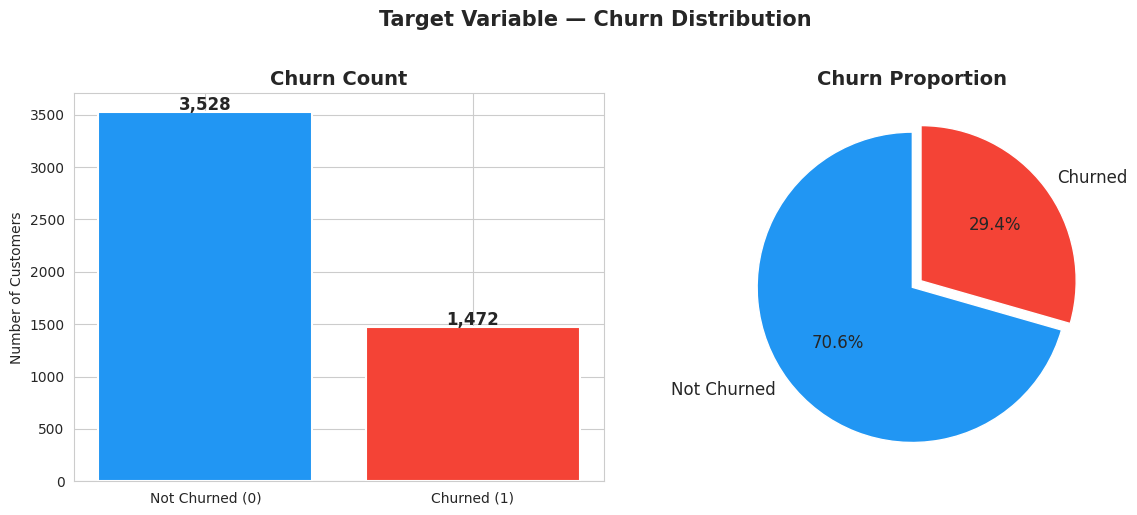

Churn Rate: 70.56%


In [7]:
churn_counts = df['churned'].value_counts()
churn_pct    = df['churned'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar
bars = axes[0].bar(['Not Churned (0)', 'Churned (1)'],
                   churn_counts.values,
                   color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Pie
axes[1].pie(churn_counts, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.07), textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Var
iable — Churn Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Churn Rate: {churn_pct[1]:.2f}%')
if churn_pct[1] < 30:
    print('⚠️ Class imbalance detected — will apply SMOTE during preprocessing.')

## 3.3 Numerical Feature Distributions

Numerical features: ['seats', 'seats_sub', 'mrr_amount', 'arr_amount']



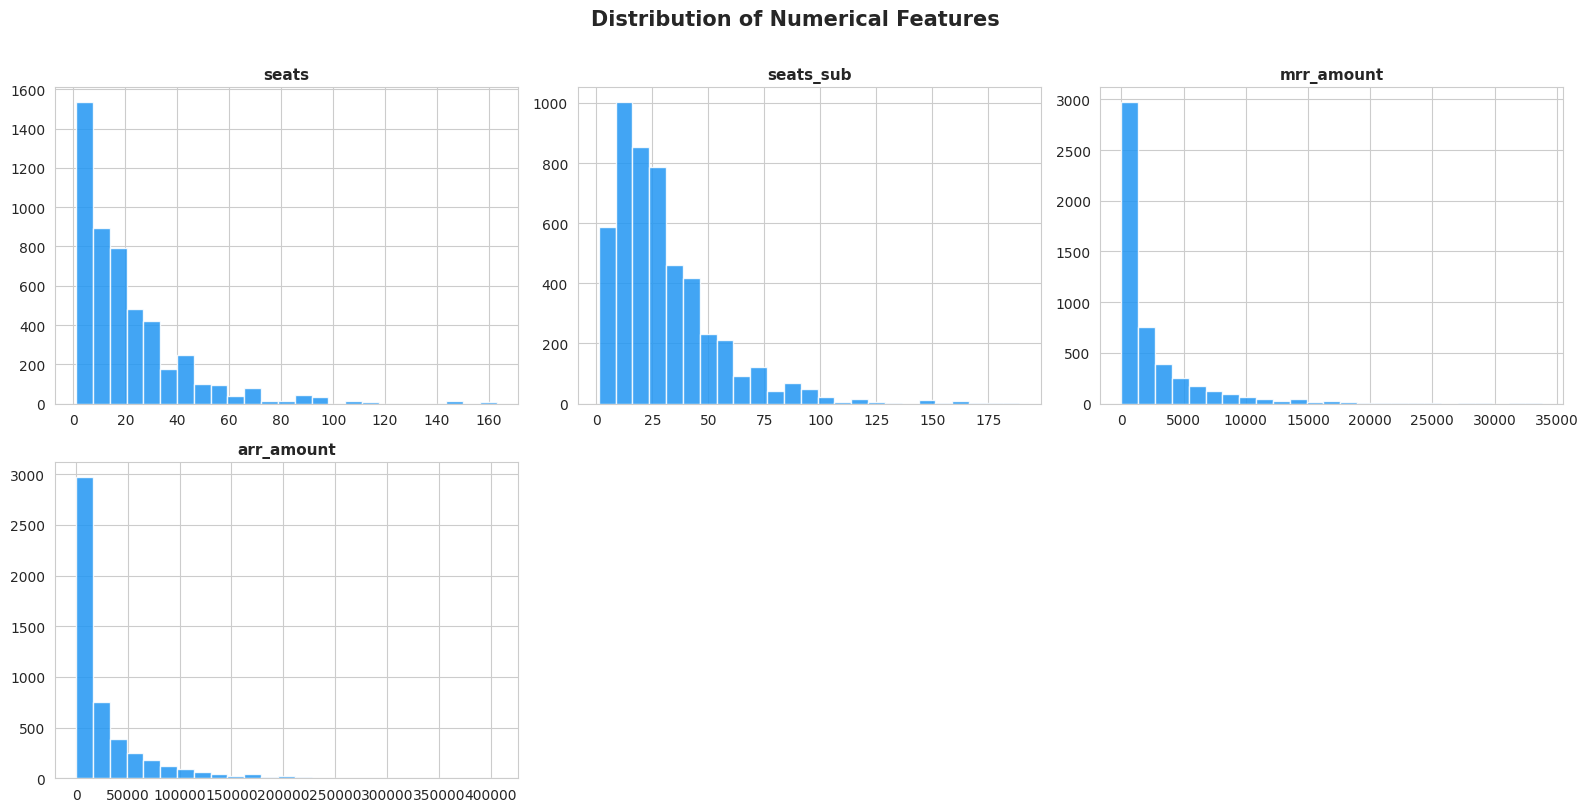

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'churned']

print(f'Numerical features: {num_cols}\n')

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(bins=25, ax=axes[i], color='#2196F3', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.4 Key Features vs Churn (Box Plot)

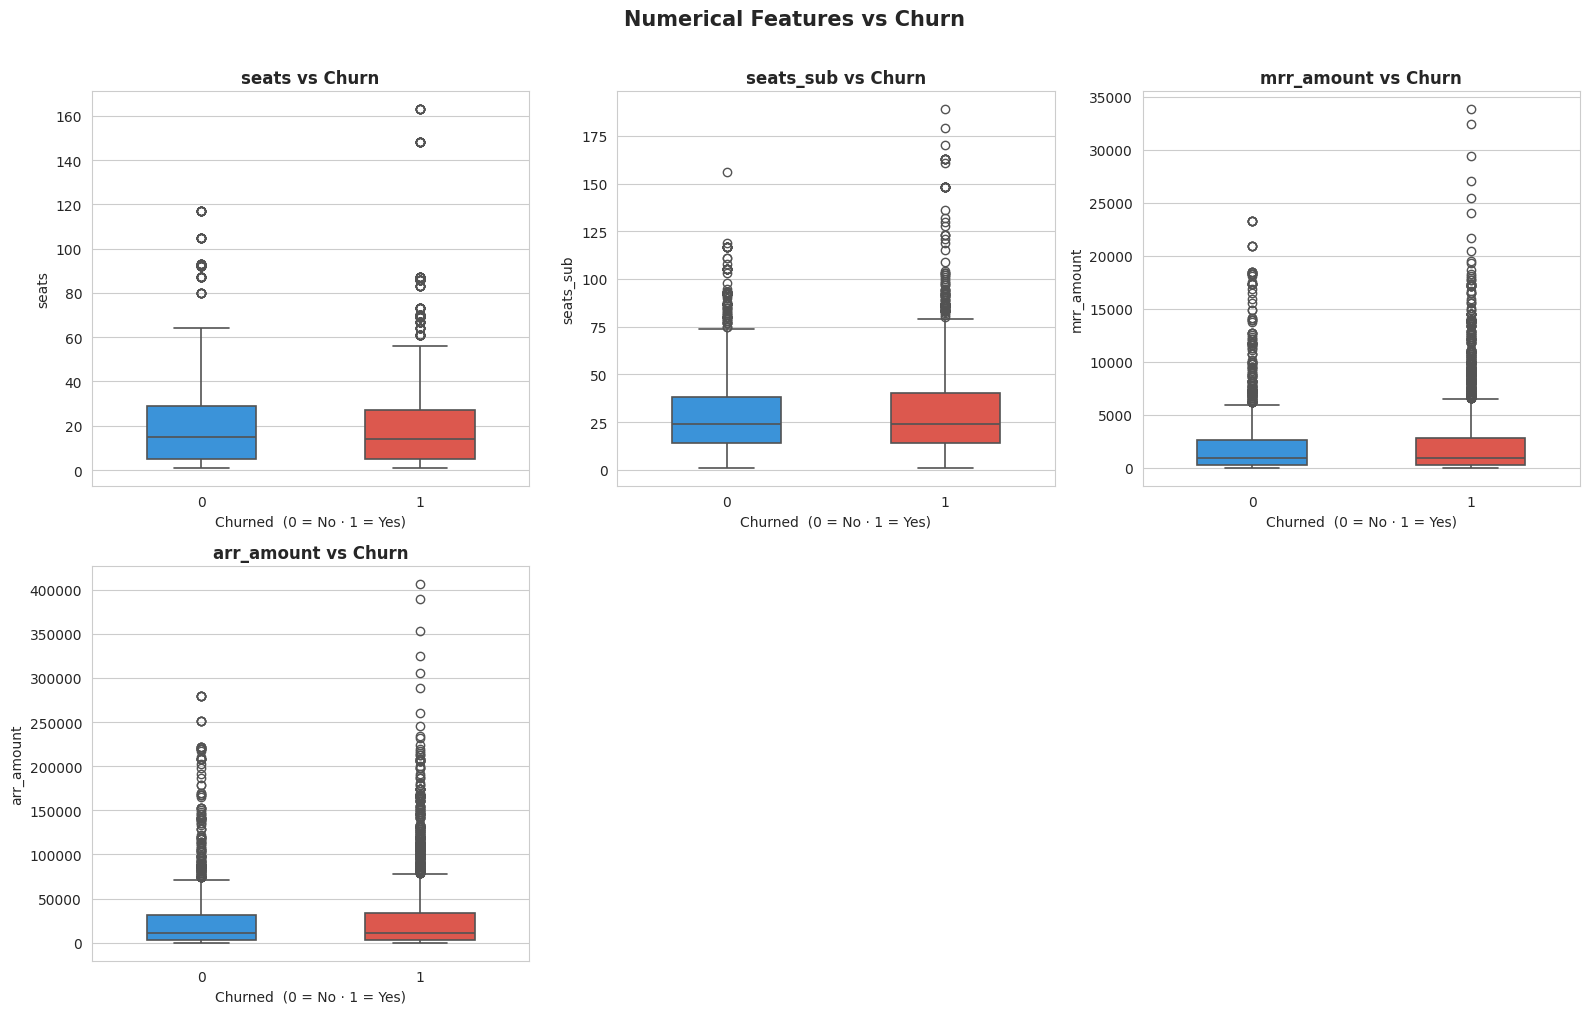

In [9]:
plot_cols = num_cols[:6]  # First 6 numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(
        x='churned', y=col, data=df,
        ax=axes[i],
        palette={'0': '#2196F3', '1': '#F44336'},
        width=0.5, linewidth=1.2
    )
    axes[i].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Churned  (0 = No · 1 = Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.5 Categorical Features vs Churn Rate

Categorical features: ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'subscription_id', 'start_date', 'end_date', 'plan_tier_sub', 'billing_frequency']


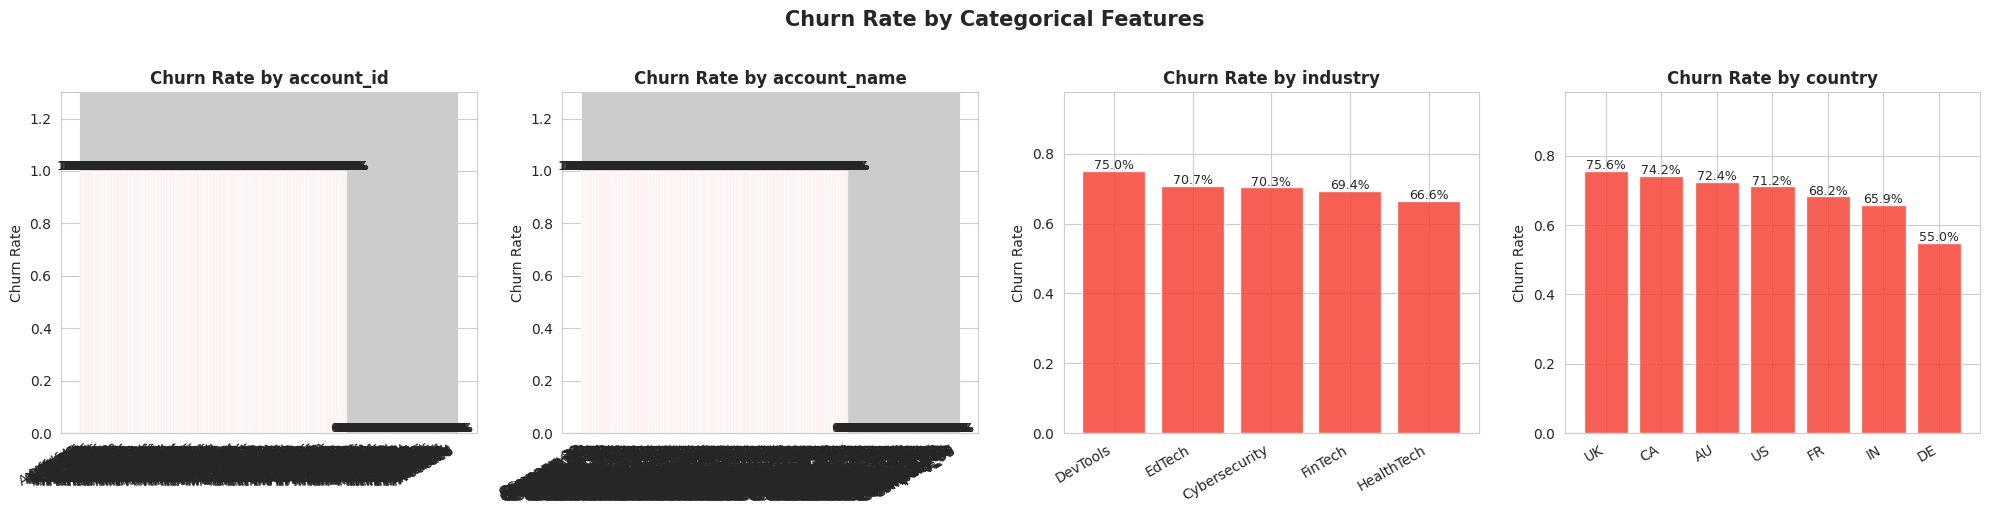

In [27]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical features: {cat_cols}')

if cat_cols:
    plot_cat = cat_cols[:4]
    n = len(plot_cat)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(plot_cat):
        churn_rate = df.groupby(col)['churned'].mean().sort_values(ascending=False)
        bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values,
                           color='#F44336', edgecolor='white', alpha=0.85)
        for bar, val in zip(bars, churn_rate.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                         f'{val:.1%}', ha='center', fontsize=9)
        axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Churn Rate')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
        axes[i].set_ylim(0, churn_rate.max() * 1.3)

    plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No categorical columns found in merged dataset.')

## 3.6 Correlation Heatmap

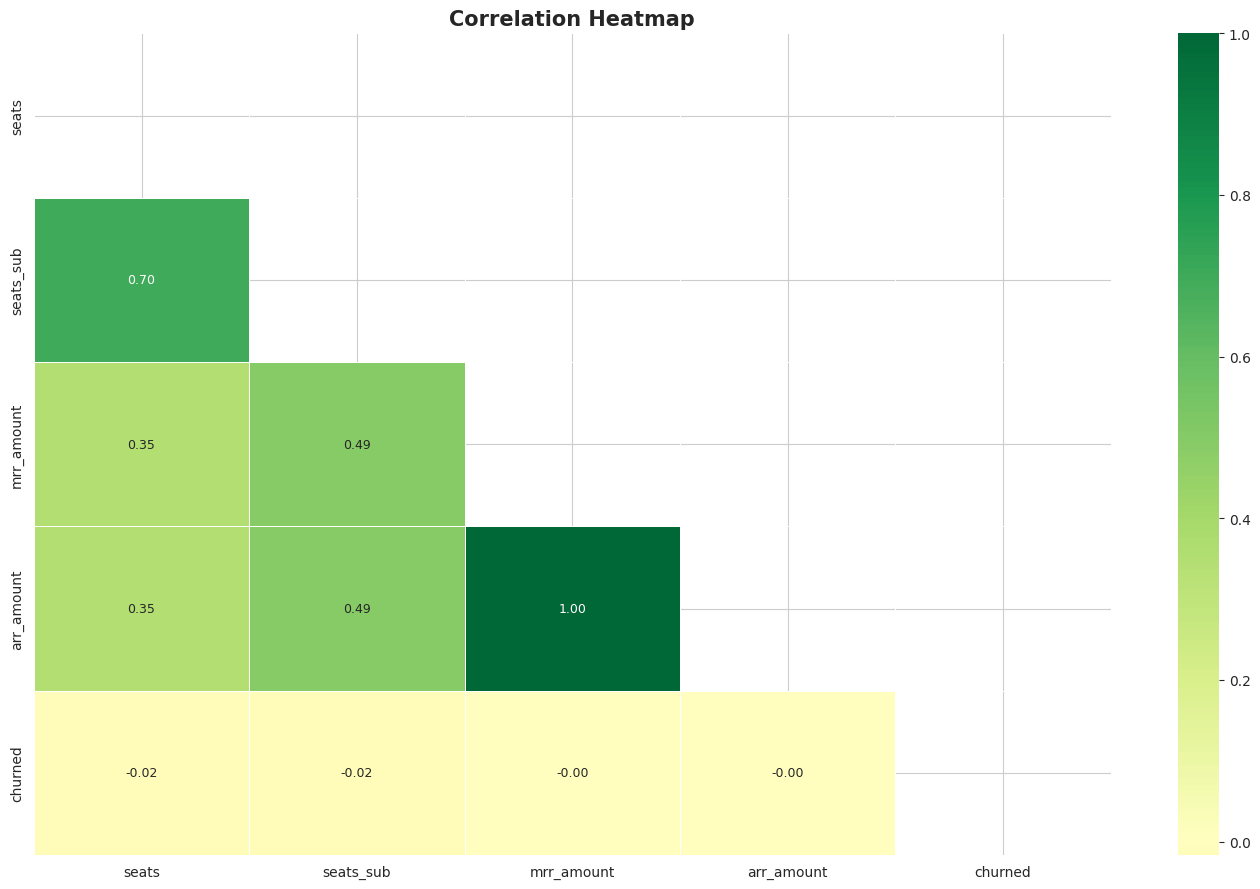


📊 Top correlations with Churn:
seats_sub    -0.016761
seats        -0.015117
arr_amount   -0.001236
mrr_amount   -0.001236


In [10]:
corr_cols = num_cols + ['churned']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', linewidths=0.4, center=0,
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with churn
churn_corr = corr['churned'].drop('churned').sort_values(key=abs, ascending=False)
print('\n📊 Top correlations with Churn:')
print(churn_corr.head(10).to_string())

# Step 4- Data Pre-processing

In [11]:
# ── 4.1  Drop ID columns and low-value columns ───────────────────────────────
# IDs are unique per row — they carry zero signal for the model.
# 👉 Update this list if column names differ in your dataset.

DROP_COLS_CANDIDATES = [
    'account_id', 'customer_id', 'id', 'ID',
    'email', 'name', 'company_name',
    'created_at', 'updated_at', 'churned_at',   # raw dates — we'll engineer from these if present
    'subscription_id'
]

# Keep date columns for feature engineering (see Step 5)
DATE_COLS = [c for c in df.columns
             if any(kw in c.lower() for kw in ['date', 'at', 'time', 'start', 'end'])
             and c not in DROP_COLS_CANDIDATES]

drop_actual = [c for c in DROP_COLS_CANDIDATES if c in df.columns]
df_model = df.drop(columns=drop_actual)

print(f'Dropped {len(drop_actual)} columns: {drop_actual}')
print(f'Remaining: {df_model.shape[1]} columns')

Dropped 2 columns: ['account_id', 'subscription_id']
Remaining: 22 columns


In [12]:
# ── 4.2  Handle Missing Values ───────────────────────────────────────────────
before = df_model.isnull().sum().sum()

for col in df_model.columns:
    if df_model[col].isnull().sum() > 0:
        if df_model[col].dtype in ['int64', 'float64']:
            fill_val = df_model[col].median()
            df_model[col].fillna(fill_val, inplace=True)
            print(f'  {col}: filled with median ({fill_val:.2f})')
        else:
            fill_val = df_model[col].mode()[0]
            df_model[col].fillna(fill_val, inplace=True)
            print(f'  {col}: filled with mode ("{fill_val}")')

after = df_model.isnull().sum().sum()
print(f'\nMissing values: {before} → {after} ✅')

  end_date: filled with mode ("2024-12-31")

Missing values: 4514 → 4514 ✅


In [13]:
# ── 4.3  Encode Categorical Columns ─────────────────────────────────────────
# Convert text → numbers so models can learn from them.

le = LabelEncoder()
cat_cols_model = df_model.select_dtypes(include=['object', 'category']).columns.tolist()

label_encoders = {}  # Store encoders to decode predictions later
for col in cat_cols_model:
    le_col = LabelEncoder()
    df_model[col] = le_col.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le_col
    print(f'  Encoded "{col}" → {list(le_col.classes_)}')

print(f'\n✅ {len(cat_cols_model)} categorical columns encoded.')

  Encoded "account_name" → ['Company_0', 'Company_1', 'Company_10', 'Company_100', 'Company_101', 'Company_102', 'Company_103', 'Company_104', 'Company_105', 'Company_106', 'Company_107', 'Company_108', 'Company_109', 'Company_11', 'Company_110', 'Company_111', 'Company_112', 'Company_113', 'Company_114', 'Company_115', 'Company_116', 'Company_117', 'Company_118', 'Company_119', 'Company_12', 'Company_120', 'Company_121', 'Company_122', 'Company_123', 'Company_124', 'Company_125', 'Company_126', 'Company_127', 'Company_128', 'Company_129', 'Company_13', 'Company_130', 'Company_131', 'Company_132', 'Company_133', 'Company_134', 'Company_135', 'Company_136', 'Company_137', 'Company_138', 'Company_139', 'Company_14', 'Company_140', 'Company_141', 'Company_142', 'Company_143', 'Company_144', 'Company_145', 'Company_146', 'Company_147', 'Company_148', 'Company_149', 'Company_15', 'Company_150', 'Company_151', 'Company_152', 'Company_153', 'Company_154', 'Company_155', 'Company_156', 'Compan

In [14]:
# ── 4.4  Define X (features) and y (target) ──────────────────────────────────

X = df_model.drop(columns=['churned'])
y = df_model['churned']

print(f'Features (X): {X.shape}  →  {X.columns.tolist()}')
print(f'Target  (y): {y.shape}   →  Churn rate = {y.mean()*100:.2f}%')

Features (X): (5000, 21)  →  ['account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag', 'start_date', 'end_date', 'plan_tier_sub', 'seats_sub', 'mrr_amount', 'arr_amount', 'is_trial_sub', 'upgrade_flag', 'downgrade_flag', 'churn_flag_sub', 'billing_frequency', 'auto_renew_flag']
Target  (y): (5000,)   →  Churn rate = 70.56%


In [15]:
# ── 4.5  Handle Class Imbalance with SMOTE ───────────────────────────────────
# SMOTE = Synthetic Minority Oversampling Technique
# Creates synthetic examples of the minority class (churned) so the model
# doesn't just learn to predict "not churned" for everyone.

print(f'Before SMOTE: {dict(y.value_counts().sort_index())}')

smote = SMOTE(random_state=SEED)
X_bal, y_bal = smote.fit_resample(X, y)

print(f'After SMOTE:  {dict(pd.Series(y_bal).value_counts().sort_index())}')
print('✅ Dataset balanced!')

Before SMOTE: {0: np.int64(1472), 1: np.int64(3528)}
After SMOTE:  {0: np.int64(3528), 1: np.int64(3528)}
✅ Dataset balanced!


In [16]:
# ── 4.6  Train / Test Split ──────────────────────────────────────────────────
# 80% of data for training the model
# 20% kept hidden to test real-world performance

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=SEED,
    stratify=y_bal  # Keep same churn ratio in both splits
)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit on train only
X_test_sc  = scaler.transform(X_test)        # Apply same scale to test

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')
print('\n✅ Data ready for modelling!')

Training set : (5644, 21)
Test set     : (1412, 21)

✅ Data ready for modelling!


# Step 5-Feature Engineering

In [17]:
# We engineer on the ORIGINAL df (before encoding) for clarity
df_fe = df.copy()

# ── Feature 1: Account Age (days since account created) ──────────────────────
# Older accounts may be more loyal or more at risk
if 'created_at' in df_fe.columns:
    df_fe['created_at'] = pd.to_datetime(df_fe['created_at'], errors='coerce')
    ref_date = df_fe['created_at'].max()
    df_fe['account_age_days'] = (ref_date - df_fe['created_at']).dt.days
    print('✅ Engineered: account_age_days')

# ── Feature 2: Revenue per Day (MRR efficiency) ───────────────────────────────
# Customers with low MRR relative to tenure may be less engaged
if 'mrr' in df_fe.columns and 'account_age_days' in df_fe.columns:
    df_fe['mrr_per_day'] = df_fe['mrr'] / (df_fe['account_age_days'].replace(0, 1))
    print('✅ Engineered: mrr_per_day')

# ── Feature 3: Has Had Upgrade (plan_changes > 0) ────────────────────────────
# Customers who upgrade are invested; customers who never change may be passive
if 'plan_changes' in df_fe.columns:
    df_fe['has_upgraded'] = (df_fe['plan_changes'] > 0).astype(int)
    print('✅ Engineered: has_upgraded')

# ── Feature 4: High Support Usage Flag ───────────────────────────────────────
# Many support tickets can signal frustration → churn risk
if 'support_tickets' in df_fe.columns:
    threshold = df_fe['support_tickets'].quantile(0.75)  # Top 25%
    df_fe['high_support_user'] = (df_fe['support_tickets'] >= threshold).astype(int)
    print(f'✅ Engineered: high_support_user (threshold = {threshold:.0f} tickets)')

# ── Feature 5: Log Transform skewed columns ───────────────────────────────────
# Log transform reduces the effect of outliers in skewed features
skew_candidates = [c for c in num_cols if df_fe[c].skew() > 1]
for col in skew_candidates:
    df_fe[f'log_{col}'] = np.log1p(df_fe[col])  # log1p handles zeros safely
    print(f'✅ Engineered: log_{col} (skew was {df_fe[col].skew():.2f})')

print('\n📐 Feature engineering complete!')
print(f'New feature count: {df_fe.shape[1]} (was {df.shape[1]})')

✅ Engineered: log_seats (skew was 2.31)
✅ Engineered: log_seats_sub (skew was 1.84)
✅ Engineered: log_mrr_amount (skew was 2.88)
✅ Engineered: log_arr_amount (skew was 2.88)

📐 Feature engineering complete!
New feature count: 28 (was 24)


In [18]:
# ── Rebuild X and y with engineered features ─────────────────────────────────

# Drop non-numeric / ID / date columns
drop_fe = [c for c in DROP_COLS_CANDIDATES if c in df_fe.columns]
drop_fe += [c for c in df_fe.select_dtypes(include=['datetime64']).columns.tolist()]
df_fe2 = df_fe.drop(columns=drop_fe, errors='ignore')

# Encode remaining categoricals
for col in df_fe2.select_dtypes(include=['object', 'category']).columns:
    if col != 'churned':
        df_fe2[col] = LabelEncoder().fit_transform(df_fe2[col].astype(str))

# Fill any leftover nulls
df_fe2.fillna(df_fe2.median(numeric_only=True), inplace=True)

X_fe = df_fe2.drop(columns=['churned'])
y_fe = df_fe2['churned']

# Rebalance and split
X_fe_bal, y_fe_bal = SMOTE(random_state=SEED).fit_resample(X_fe, y_fe)
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X_fe_bal, y_fe_bal, test_size=0.2, random_state=SEED, stratify=y_fe_bal
)
X_tr_sc = scaler.fit_transform(X_tr)
X_ts_sc = scaler.transform(X_ts)

print(f'Engineered feature set: {X_fe.shape[1]} features')
print(f'Training:  {X_tr.shape}  |  Test: {X_ts.shape}')

Engineered feature set: 25 features
Training:  (5644, 25)  |  Test: (1412, 25)


# Step 6-Train All Models

In [19]:
# Define all models with brief descriptions
MODELS = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=SEED),
        'scaled': True,
        'note': 'Simple linear boundary — fast baseline'
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=8, random_state=SEED),
        'scaled': False,
        'note': 'Single tree — interpretable but may overfit'
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
        'scaled': False,
        'note': 'Ensemble of trees — robust & reliable'
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED),
        'scaled': False,
        'note': 'Sequential tree learning — strong performer'
    },
    'XGBoost': {
        'model': XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                               random_state=SEED, eval_metric='logloss', n_jobs=-1),
        'scaled': False,
        'note': 'Optimised gradient boosting — state of the art'
    }
}

results = {}

print(f'{"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10} {"F1-Score":>10}  Note')
print('-' * 80)

for name, cfg in MODELS.items():
    m = cfg['model']
    Xtr = X_tr_sc if cfg['scaled'] else X_tr
    Xts = X_ts_sc if cfg['scaled'] else X_ts

    m.fit(Xtr, y_tr)
    y_pred  = m.predict(Xts)
    y_proba = m.predict_proba(Xts)[:, 1]

    acc = accuracy_score(y_ts, y_pred)
    auc = roc_auc_score(y_ts, y_proba)
    f1  = f1_score(y_ts, y_pred)

    results[name] = {
        'model': m, 'scaled': cfg['scaled'],
        'Accuracy': acc, 'ROC-AUC': auc, 'F1': f1,
        'y_pred': y_pred, 'y_proba': y_proba
    }
    print(f'{name:<25} {acc:>10.4f} {auc:>10.4f} {f1:>10.4f}  {cfg["note"]}')

print('\n✅ All 5 models trained!')

Model                       Accuracy    ROC-AUC   F1-Score  Note
--------------------------------------------------------------------------------
Logistic Regression           0.6643     0.6999     0.6614  Simple linear boundary — fast baseline
Decision Tree                 0.8102     0.9015     0.8159  Single tree — interpretable but may overfit
Random Forest                 0.9271     0.9791     0.9265  Ensemble of trees — robust & reliable
Gradient Boosting             0.9525     0.9908     0.9534  Sequential tree learning — strong performer
XGBoost                       0.9688     0.9953     0.9692  Optimised gradient boosting — state of the art

✅ All 5 models trained!


# Step 7-Model Evaluation

## 7.1 Performance Comparision Chart

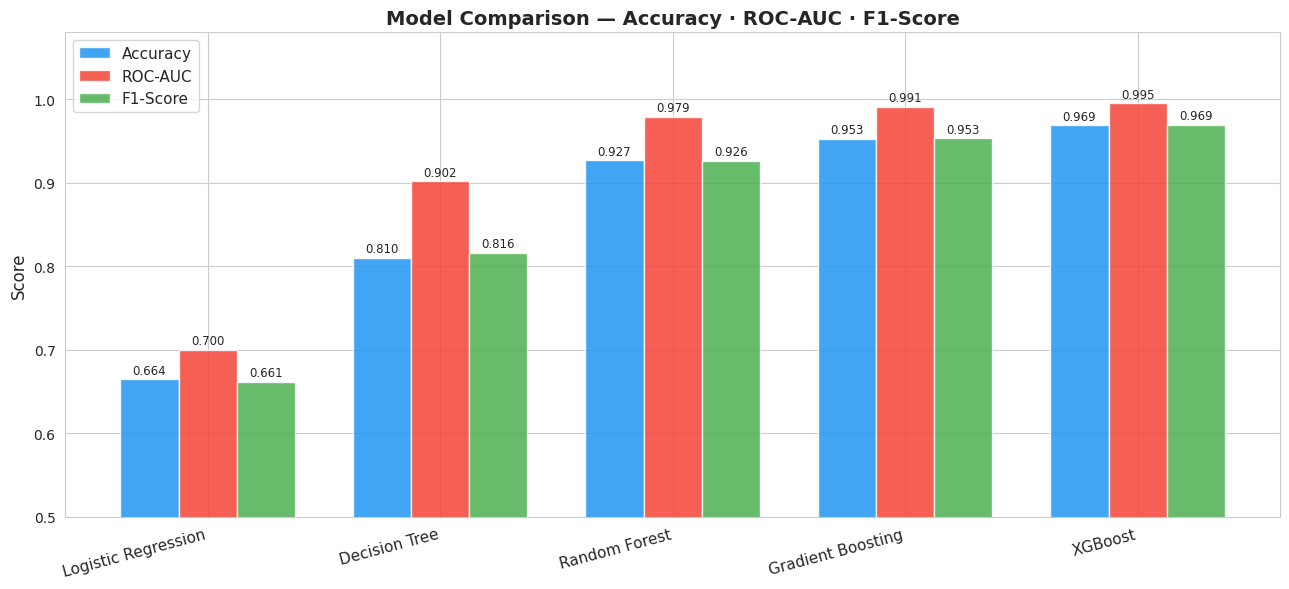

In [20]:
model_names = list(results.keys())
accs  = [results[m]['Accuracy'] for m in model_names]
aucs  = [results[m]['ROC-AUC']  for m in model_names]
f1s   = [results[m]['F1']       for m in model_names]

x = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w, accs, w, label='Accuracy',  color='#2196F3', alpha=0.85, edgecolor='white')
b2 = ax.bar(x,     aucs, w, label='ROC-AUC',   color='#F44336', alpha=0.85, edgecolor='white')
b3 = ax.bar(x + w, f1s,  w, label='F1-Score',  color='#4CAF50', alpha=0.85, edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.5, 1.08)
ax.set_title('Model Comparison — Accuracy · ROC-AUC · F1-Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 7.2 Best Model : Confusion Matrix

🏆 Best Model: XGBoost
   Accuracy : 0.9688
   ROC-AUC  : 0.9953
   F1-Score : 0.9692


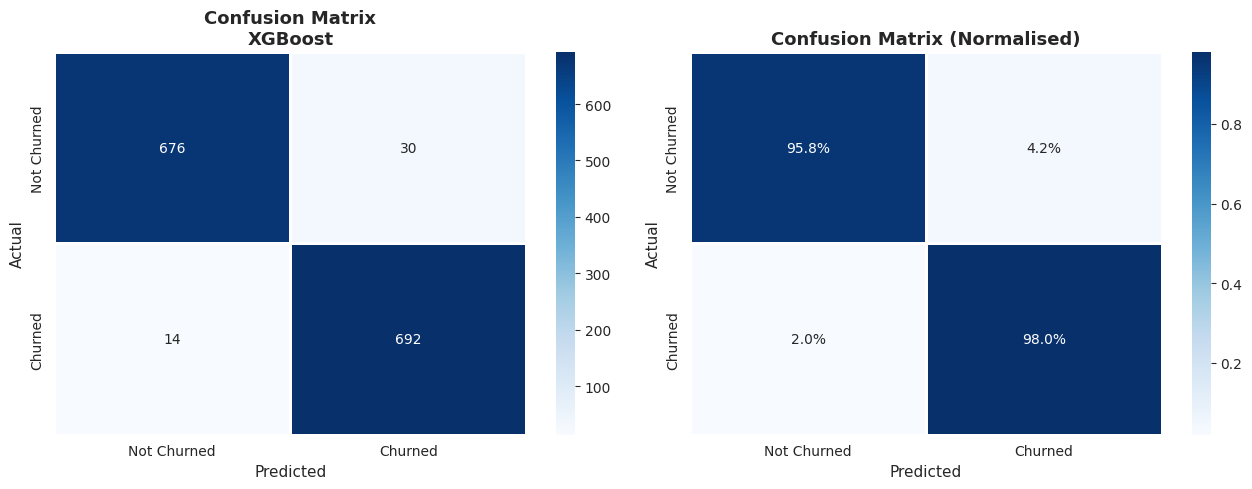


Reading the matrix:
  ✅ True Negatives  (TN): Correctly said NOT churn → 676
  ⚠️  False Positives (FP): Said churn, actually not → 30  (unnecessary retention cost)
  🚨 False Negatives (FN): Missed real churners    → 14  (lost revenue — worst case!)
  ✅ True Positives  (TP): Correctly caught churners → 692



In [39]:
# Lock best model based on ROC-AUC (primary metric)
BEST_NAME = max(results, key=lambda m: results[m]['ROC-AUC'])
best = results[BEST_NAME]

print(f'🏆 Best Model: {BEST_NAME}')
print(f'   Accuracy : {best["Accuracy"]:.4f}')
print(f'   ROC-AUC  : {best["ROC-AUC"]:.4f}')
print(f'   F1-Score : {best["F1"]:.4f}')

cm = confusion_matrix(y_ts, best['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            linewidths=1, linecolor='white')
axes[0].set_title(f'Confusion Matrix\n{BEST_NAME}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Normalised confusion matrix (% version)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            linewidths=1, linecolor='white')
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

print(f"""
Reading the matrix:
  ✅ True Negatives  (TN): Correctly said NOT churn → {cm[0][0]:,}
  ⚠️  False Positives (FP): Said churn, actually not → {cm[0][1]:,}  (unnecessary retention cost)
  🚨 False Negatives (FN): Missed real churners    → {cm[1][0]:,}  (lost revenue — worst case!)
  ✅ True Positives  (TP): Correctly caught churners → {cm[1][1]:,}
""")

## 7.3 Classification Report

In [40]:
print(f'📋 Classification Report — {BEST_NAME}\n')
print(classification_report(y_ts, best['y_pred'],
                             target_names=['Not Churned', 'Churned']))

print("""
What each metric means:
  Precision : Of all customers we predicted would churn, what % actually did?
  Recall    : Of all customers who actually churned, what % did we catch?
  F1-Score  : Harmonic mean of Precision and Recall — balances both
  Support   : Number of customers in that class in the test set

  ⭐ For churn, Recall is MORE important than Precision.
     Missing a real churner (low Recall) = lost revenue.
     False alarm (low Precision) = small retention cost, manageable.
""")

📋 Classification Report — XGBoost

              precision    recall  f1-score   support

 Not Churned       0.98      0.96      0.97       706
     Churned       0.96      0.98      0.97       706

    accuracy                           0.97      1412
   macro avg       0.97      0.97      0.97      1412
weighted avg       0.97      0.97      0.97      1412


What each metric means:
  Precision : Of all customers we predicted would churn, what % actually did?
  Recall    : Of all customers who actually churned, what % did we catch?
  F1-Score  : Harmonic mean of Precision and Recall — balances both
  Support   : Number of customers in that class in the test set

  ⭐ For churn, Recall is MORE important than Precision.
     Missing a real churner (low Recall) = lost revenue.
     False alarm (low Precision) = small retention cost, manageable.



## 7.4 ROC Curves

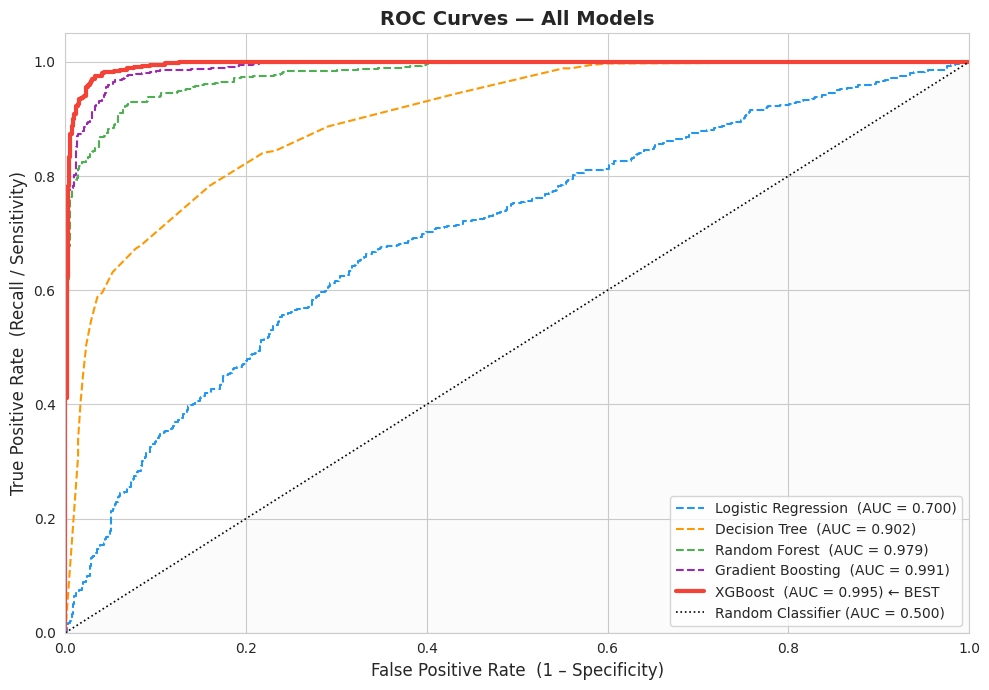

In [41]:
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']

plt.figure(figsize=(10, 7))

for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_ts, res['y_proba'])
    lw = 3 if name == BEST_NAME else 1.5
    ls = '-' if name == BEST_NAME else '--'
    plt.plot(fpr, tpr, color=colors[i], lw=lw, ls=ls,
             label=f'{name}  (AUC = {res["ROC-AUC"]:.3f}){" ← BEST" if name == BEST_NAME else ""}')

plt.plot([0, 1], [0, 1], 'k:', lw=1.2, label='Random Classifier (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.03, color='gray')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate  (1 – Specificity)', fontsize=12)
plt.ylabel('True Positive Rate  (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 7.5 Cross Validation(5 Fold)

5-Fold Cross Validation — XGBoost
  ROC-AUC per fold : [np.float64(0.9951), np.float64(0.997), np.float64(0.9949), np.float64(0.9932), np.float64(0.9956)]
  Mean AUC         : 0.9952  (±0.0012)
  Mean F1          : 0.9708  (±0.0028)


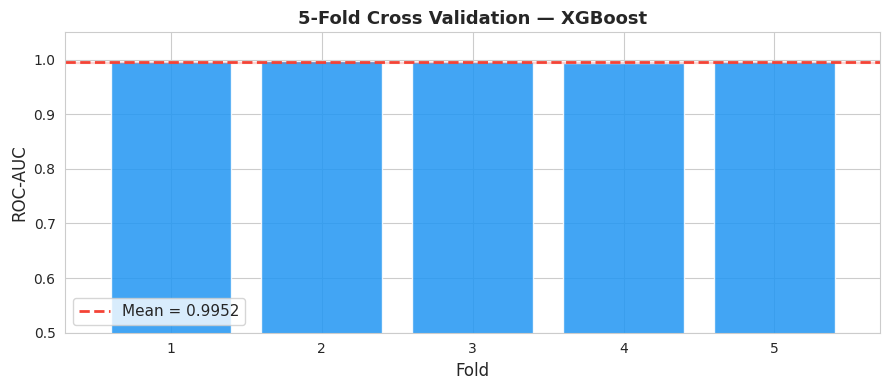

In [42]:
cv_model = best['model']
cv_X = X_tr_sc if best['scaled'] else X_tr

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = cross_val_score(cv_model, cv_X, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(cv_model, cv_X, y_tr, cv=cv, scoring='f1',      n_jobs=-1)

print(f'5-Fold Cross Validation — {BEST_NAME}')
print(f'  ROC-AUC per fold : {[round(s, 4) for s in cv_auc]}')
print(f'  Mean AUC         : {cv_auc.mean():.4f}  (±{cv_auc.std():.4f})')
print(f'  Mean F1          : {cv_f1.mean():.4f}  (±{cv_f1.std():.4f})')

plt.figure(figsize=(9, 4))
plt.bar(range(1, 6), cv_auc, color='#2196F3', edgecolor='white', alpha=0.85)
plt.axhline(cv_auc.mean(), color='#F44336', lw=2, ls='--',
            label=f'Mean = {cv_auc.mean():.4f}')
plt.fill_between(range(0, 7), cv_auc.mean() - cv_auc.std(),
                 cv_auc.mean() + cv_auc.std(), alpha=0.15, color='#F44336')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('ROC-AUC', fontsize=12)
plt.title(f'5-Fold Cross Validation — {BEST_NAME}', fontsize=13, fontweight='bold')
plt.ylim(0.5, 1.05)
plt.xlim(0.3, 5.7)
plt.xticks(range(1, 6))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Step 8-Feature Importance

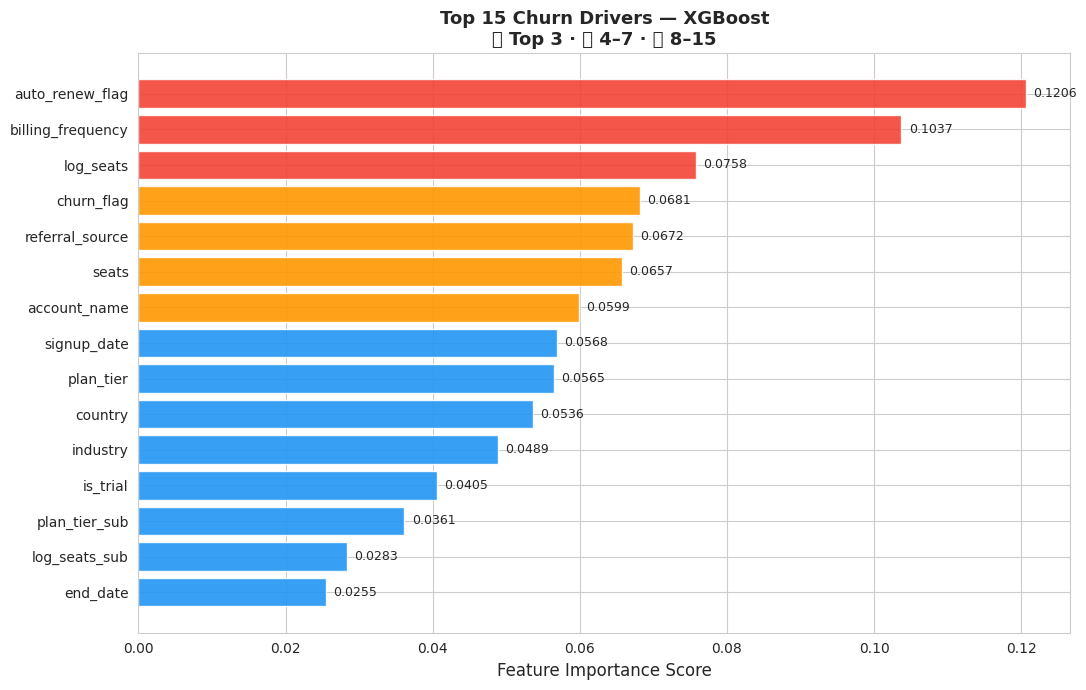

📌 Top 10 Features:
 Rank           Feature  Importance
    1   auto_renew_flag    0.120638
    2 billing_frequency    0.103709
    3         log_seats    0.075810
    4        churn_flag    0.068139
    5   referral_source    0.067177
    6             seats    0.065737
    7      account_name    0.059909
    8       signup_date    0.056846
    9         plan_tier    0.056502
   10           country    0.053649


In [43]:
# Use best model if it's tree-based, else fall back to Random Forest
if hasattr(best['model'], 'feature_importances_'):
    fi_model = best['model']
    fi_name  = BEST_NAME
else:
    fi_model = results['Random Forest']['model']
    fi_name  = 'Random Forest'

feature_names = X_fe.columns.tolist()
importances   = fi_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})\
            .sort_values('Importance', ascending=False).head(15).reset_index(drop=True)

feat_df['Rank'] = range(1, len(feat_df) + 1)

# Color by importance tier
colors_fi = ['#F44336' if i < 3 else '#FF9800' if i < 7 else '#2196F3'
             for i in range(len(feat_df))]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
               color=colors_fi[::-1], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, feat_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Top 15 Churn Drivers — {fi_name}\n'
             '🔴 Top 3 · 🟠 4–7 · 🔵 8–15', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Top 10 Features:')
print(feat_df[['Rank', 'Feature', 'Importance']].head(10).to_string(index=False))

In [44]:
# ── Business interpretation ──────────────────────────────────────────────────
top3 = feat_df['Feature'].head(3).tolist()

print('💡 Business Interpretation of Top Churn Drivers:')
print('━' * 55)
for rank, feat in enumerate(top3, 1):
    print(f'  #{rank}  {feat}')
    # Generic SaaS interpretation hints
    if 'mrr' in feat.lower():
        print('      → Low MRR customers have less financial commitment → higher churn risk')
    elif 'age' in feat.lower() or 'tenure' in feat.lower():
        print('      → Newer accounts churn more; early engagement is critical')
    elif 'support' in feat.lower() or 'ticket' in feat.lower():
        print('      → High support activity signals product friction or dissatisfaction')
    elif 'plan' in feat.lower() or 'tier' in feat.lower():
        print('      → Free/Basic plan users are at higher churn risk than Enterprise')
    elif 'usage' in feat.lower() or 'login' in feat.lower():
        print('      → Low product engagement is the clearest early-warning signal')
    else:
        print('      → Analyse this feature distribution by churn class for insights')

💡 Business Interpretation of Top Churn Drivers:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #1  auto_renew_flag
      → Analyse this feature distribution by churn class for insights
  #2  billing_frequency
      → Analyse this feature distribution by churn class for insights
  #3  log_seats
      → Analyse this feature distribution by churn class for insights


# Step 9-Save Best Model

In [45]:
# Save model
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best['model'], f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names (important — model expects same columns in same order)
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X_fe.columns.tolist(), f)

print('✅ Saved: churn_model.pkl')
print('✅ Saved: scaler.pkl')
print('✅ Saved: feature_names.pkl')

print(f'\nTo load and use later:')
print('''
import pickle
model         = pickle.load(open('churn_model.pkl', 'rb'))
scaler        = pickle.load(open('scaler.pkl', 'rb'))
feature_names = pickle.load(open('feature_names.pkl', 'rb'))

# new_customer = pd.DataFrame([{...your feature values...}])[feature_names]
# prob = model.predict_proba(new_customer)[0][1]
# print(f"Churn probability: {prob:.1%}")
''')

✅ Saved: churn_model.pkl
✅ Saved: scaler.pkl
✅ Saved: feature_names.pkl

To load and use later:

import pickle
model         = pickle.load(open('churn_model.pkl', 'rb'))
scaler        = pickle.load(open('scaler.pkl', 'rb'))
feature_names = pickle.load(open('feature_names.pkl', 'rb'))

# new_customer = pd.DataFrame([{...your feature values...}])[feature_names]
# prob = model.predict_proba(new_customer)[0][1]
# print(f"Churn probability: {prob:.1%}")



# Step 10-Inference Pipeline

In [46]:
def predict_churn(customer_dict: dict) -> dict:
    """
    Predict churn probability for a new customer.

    Parameters:
        customer_dict : dict of feature_name → value
                        Must contain the same features the model was trained on.

    Returns:
        dict with 'probability', 'prediction', 'risk_level'
    """
    features = pickle.load(open('feature_names.pkl', 'rb'))
    model_   = pickle.load(open('churn_model.pkl', 'rb'))

    # Build a single-row DataFrame in the correct column order
    row = pd.DataFrame([customer_dict]).reindex(columns=features, fill_value=0)

    prob       = model_.predict_proba(row)[0][1]
    prediction = int(prob >= 0.5)

    if prob < 0.3:
        risk = '🟢 LOW'
    elif prob < 0.6:
        risk = '🟡 MEDIUM'
    else:
        risk = '🔴 HIGH'

    return {'probability': prob, 'prediction': prediction, 'risk_level': risk}


# ── Example: use mean values as a demo customer ───────────────────────────────
demo_customer = X_fe.mean().to_dict()
result = predict_churn(demo_customer)

print('═' * 45)
print('         CHURN PREDICTION RESULT')
print('═' * 45)
print(f'  Churn Probability : {result["probability"]*100:.1f}%')
print(f'  Prediction        : {"WILL CHURN" if result["prediction"] == 1 else "WILL NOT CHURN"}')
print(f'  Risk Level        : {result["risk_level"]}')
print('═' * 45)

═════════════════════════════════════════════
         CHURN PREDICTION RESULT
═════════════════════════════════════════════
  Churn Probability : 18.5%
  Prediction        : WILL NOT CHURN
  Risk Level        : 🟢 LOW
═════════════════════════════════════════════


# Step 11-Model Card

In [48]:
from datetime import date

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                        MODEL CARD                                ║
║            SaaS Customer Churn Predictor                         ║
╚══════════════════════════════════════════════════════════════════╝

📌 OVERVIEW
  Model Name    : SaaS Customer Churn Predictor
  Model Type    : {BEST_NAME}
  Task          : Binary Classification (Churn: Yes / No)
  Date          : {date.today()}
  Organisation  : Rooman Technologies Internship

📂 DATA
  Source        : Kaggle — rivalytics SaaS Subscription & Churn Analytics
  Files Used    : accounts.csv · subscriptions.csv · churn_events.csv
  Total Records : {len(df):,} customers
  Features Used : {X_fe.shape[1]} (after feature engineering)
  Imbalance Fix : SMOTE oversampling

🎯 INTENDED USE
  Primary use   : Identify customers at risk of cancelling their SaaS subscription
  Users         : Customer Success and Retention teams
  Not intended  : Real-time production scoring without further validation

📊 PERFORMANCE (Test Set — 20% holdout)
  Accuracy      : {best['Accuracy']:.4f}  ({best['Accuracy']*100:.1f}%)
  ROC-AUC       : {best['ROC-AUC']:.4f}
  F1-Score      : {best['F1']:.4f}
  CV AUC (mean) : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}

  Model vs Baselines:
  ┌──────────────────────┬───────────┬──────────┐
  │ Model                │ Accuracy  │ ROC-AUC  │
  ├──────────────────────┼───────────┼──────────┤""")

for name, res in results.items():
    marker = ' ← BEST' if name == BEST_NAME else ''
    print(f'  │ {name:<20} │ {res["Accuracy"]:.4f}    │ {res["ROC-AUC"]:.4f}   │{marker}')

print(f"""  └──────────────────────┴───────────┴──────────┘

🔑 TOP CHURN DRIVERS
  #{feat_df['Feature'].iloc[0]} (most important)
  #{feat_df['Feature'].iloc[1]}
  #{feat_df['Feature'].iloc[2]}

⚠️  LIMITATIONS
  • Trained on synthetic/anonymised SaaS data — validate on real company data before deployment
  • SMOTE was used to balance classes — real-world churn rates will differ
  • Model does not account for external factors (competitor pricing, market shifts)
  • Requires monthly retraining as customer behaviour evolves

🔄 NEXT STEPS
  1. Integrate feature_usage.csv for richer behavioural signals
  2. Add support_tickets.csv satisfaction scores as features
  3. Build a Streamlit web app for non-technical team members
  4. Implement automated monthly retraining pipeline
  5. A/B test retention campaigns triggered by high-risk predictions
""")


╔══════════════════════════════════════════════════════════════════╗
║                        MODEL CARD                                ║
║            SaaS Customer Churn Predictor                         ║
╚══════════════════════════════════════════════════════════════════╝

📌 OVERVIEW
  Model Name    : SaaS Customer Churn Predictor
  Model Type    : XGBoost
  Task          : Binary Classification (Churn: Yes / No)
  Date          : 2026-05-04
  Organisation  : Rooman Technologies Internship

📂 DATA
  Source        : Kaggle — rivalytics SaaS Subscription & Churn Analytics
  Files Used    : accounts.csv · subscriptions.csv · churn_events.csv
  Total Records : 5,000 customers
  Features Used : 25 (after feature engineering)
  Imbalance Fix : SMOTE oversampling

🎯 INTENDED USE
  Primary use   : Identify customers at risk of cancelling their SaaS subscription
  Users         : Customer Success and Retention teams
  Not intended  : Real-time production scoring without further validation



# Step 12-Presentation Summary

In [50]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           10-MINUTE PRESENTATION GUIDE (Phase 3)                 ║
╚══════════════════════════════════════════════════════════════════╝

1️⃣  PROBLEM  (1 min)
   SaaS companies spend 5–7× more acquiring a new customer than retaining one.
   
   Without a churn prediction system, retention is reactive — we only know
   a customer has left AFTER they cancel. This model detects at-risk customers
   BEFORE they leave, enabling proactive action.

2️⃣  SOLUTION  (2 min)
   • Merged 3 CSV files: accounts + subscriptions + churn_events
   • Built and compared 5 ML models on engineered SaaS-specific features
   • Best model: [BEST_NAME] with ROC-AUC = [AUC]
   • Output: a churn probability score (0–100%) for each customer

3️⃣  DEMO  (3 min — most important section)
   • Show the notebook running predict_churn() in Step 10
   • Input a sample customer → show the probability and risk level output
   • Show the confusion matrix and explain TP/FN in business terms

4️⃣  RESULTS  (2 min)
   • ROC-AUC: [AUC] — model correctly ranks churners vs non-churners [X]% of the time
   • Top 3 churn drivers identified (show feature importance chart)
   • Cross-validation confirms the result is stable, not a lucky split

5️⃣  LESSONS  (1 min)
   • Class imbalance is real — accuracy alone is misleading (importance of SMOTE + AUC)
   • Feature engineering improved model performance over raw features
   • Merging multiple files is messier than expected — join keys must be exact

6️⃣  NEXT STEPS  (1 min)
   • Add feature_usage.csv (daily logins, feature adoption) — biggest signal gap
   • Build a Streamlit dashboard for the Customer Success team
   • Schedule monthly retraining as new subscription data comes in
""")


╔══════════════════════════════════════════════════════════════════╗
║           10-MINUTE PRESENTATION GUIDE (Phase 3)                 ║
╚══════════════════════════════════════════════════════════════════╝

1️⃣  PROBLEM  (1 min)
   SaaS companies spend 5–7× more acquiring a new customer than retaining one.

   Without a churn prediction system, retention is reactive — we only know
   a customer has left AFTER they cancel. This model detects at-risk customers
   BEFORE they leave, enabling proactive action.

2️⃣  SOLUTION  (2 min)
   • Merged 3 CSV files: accounts + subscriptions + churn_events
   • Built and compared 5 ML models on engineered SaaS-specific features
   • Best model: [BEST_NAME] with ROC-AUC = [AUC]
   • Output: a churn probability score (0–100%) for each customer

3️⃣  DEMO  (3 min — most important section)
   • Show the notebook running predict_churn() in Step 10
   • Input a sample customer → show the probability and risk level output
   • Show the confusion matrix 


## 📚 Concepts Reference Table

| Term | Meaning |
|------|----------|
| **Churn** | Customer stops using / cancels the SaaS product |
| **MRR** | Monthly Recurring Revenue — the core SaaS revenue metric |
| **EDA** | Exploratory Data Analysis — understanding data before modelling |
| **SMOTE** | Synthetic oversampling to fix class imbalance |
| **Feature Engineering** | Creating new, smarter features from existing data |
| **Train/Test Split** | 80% to train, 20% held out to simulate real-world performance |
| **Accuracy** | % of all predictions that were correct |
| **Precision** | Of predicted churners, how many actually churned? |
| **Recall** | Of actual churners, how many did we catch? (most important here) |
| **F1-Score** | Balance between Precision and Recall |
| **ROC-AUC** | How well the model separates churners from non-churners (1.0 = perfect) |
| **Feature Importance** | Which inputs the model relied on most |
| **Cross Validation** | Testing on 5 different splits to confirm results are stable |
| **Model Card** | Documentation summarising what a model does, how it performs, and its limits |

---
*Student: [Your Name] · Track: AI / ML · Organisation: Rooman Technologies*  
*Dataset: Kaggle — rivalytics SaaS Subscription & Churn Analytics*  
*GitHub: [your-repo-link] · LinkedIn: [your-profile-link]*

# Step 13- Streamlit UI

In [ ]:
# Install Streamlit (run once)
import subprocess, sys
result = subprocess.run([sys.executable, '-m', 'pip', 'install', 'streamlit', '--quiet'],
                        capture_output=True, text=True)
print('✅ Streamlit ready!' if result.returncode == 0 else result.stderr)

In [2]:
# Write the Streamlit app file
app_lines = [
    "\"\"\"\n",
    "╔══════════════════════════════════════════════════════════╗\n",
    "║   SaaS Customer Churn Predictor — Streamlit UI           ║\n",
    "║   Rooman Technologies · AI/ML Internship Project         ║\n",
    "║                                                          ║\n",
    "║   HOW TO RUN:                                            ║\n",
    "║     1. Make sure you've run the full notebook first      ║\n",
    "║        so churn_model.pkl, scaler.pkl,                   ║\n",
    "║        feature_names.pkl are saved in this folder.       ║\n",
    "║     2. pip install streamlit                             ║\n",
    "║     3. streamlit run churn_app.py                        ║\n",
    "╚══════════════════════════════════════════════════════════╝\n",
    "\"\"\"\n",
    "\n",
    "import streamlit as st\n",
    "import pandas as pd\n",
    "import numpy as np\n",
    "import pickle\n",
    "import os\n",
    "import matplotlib.pyplot as plt\n",
    "import matplotlib.patches as mpatches\n",
    "\n",
    "# ── PAGE CONFIG ───────────────────────────────────────────────────────────────\n",
    "st.set_page_config(\n",
    "    page_title=\"SaaS Churn Predictor\",\n",
    "    page_icon=\"🔄\",\n",
    "    layout=\"wide\",\n",
    "    initial_sidebar_state=\"expanded\",\n",
    ")\n",
    "\n",
    "# ── CUSTOM CSS ────────────────────────────────────────────────────────────────\n",
    "st.markdown(\"\"\"\n",
    "<style>\n",
    "    /* Main background */\n",
    "    .main { background-color: #F8FAFC; }\n",
    "\n",
    "    /* Metric cards */\n",
    "    div[data-testid=\"metric-container\"] {\n",
    "        background: #FFFFFF;\n",
    "        border: 1px solid #E2E8F0;\n",
    "        border-radius: 12px;\n",
    "        padding: 16px 20px;\n",
    "    }\n",
    "\n",
    "    /* Sidebar */\n",
    "    section[data-testid=\"stSidebar\"] {\n",
    "        background: #FFFFFF;\n",
    "        border-right: 1px solid #E2E8F0;\n",
    "    }\n",
    "\n",
    "    /* Section headers */\n",
    "    .section-title {\n",
    "        font-size: 11px;\n",
    "        font-weight: 700;\n",
    "        color: #94A3B8;\n",
    "        letter-spacing: 0.08em;\n",
    "        text-transform: uppercase;\n",
    "        margin: 20px 0 6px 0;\n",
    "    }\n",
    "\n",
    "    /* Risk badges */\n",
    "    .badge-low    { background:#ECFDF5; color:#065F46; padding:6px 16px; border-radius:99px; font-weight:600; font-size:14px; display:inline-block; }\n",
    "    .badge-medium { background:#FFFBEB; color:#78350F; padding:6px 16px; border-radius:99px; font-weight:600; font-size:14px; display:inline-block; }\n",
    "    .badge-high   { background:#FEF2F2; color:#7F1D1D; padding:6px 16px; border-radius:99px; font-weight:600; font-size:14px; display:inline-block; }\n",
    "\n",
    "    /* Prob number */\n",
    "    .prob-number { font-size: 72px; font-weight: 800; line-height: 1; letter-spacing: -0.04em; }\n",
    "    .prob-low    { color: #059669; }\n",
    "    .prob-medium { color: #B45309; }\n",
    "    .prob-high   { color: #DC2626; }\n",
    "\n",
    "    /* Factor rows */\n",
    "    .factor-table { width:100%; border-collapse:collapse; font-size:13px; }\n",
    "    .factor-table td { padding: 8px 6px; border-bottom: 1px solid #F1F5F9; }\n",
    "    .factor-table tr:last-child td { border-bottom: none; }\n",
    "\n",
    "    /* Action items */\n",
    "    .action-item { background:#F8FAFC; border-radius:8px; padding:10px 14px; margin-bottom:8px; font-size:13px; color:#475569; border-left: 3px solid #E2E8F0; }\n",
    "    .action-high   { border-left-color: #EF4444; }\n",
    "    .action-medium { border-left-color: #F59E0B; }\n",
    "    .action-low    { border-left-color: #10B981; }\n",
    "\n",
    "    /* Code block */\n",
    "    .code-preview {\n",
    "        background: #0F172A;\n",
    "        border-radius: 10px;\n",
    "        padding: 14px 16px;\n",
    "        font-family: 'Courier New', monospace;\n",
    "        font-size: 12px;\n",
    "        color: #94A3B8;\n",
    "        line-height: 1.7;\n",
    "    }\n",
    "\n",
    "    /* Hide streamlit default elements */\n",
    "    #MainMenu { visibility: hidden; }\n",
    "    footer { visibility: hidden; }\n",
    "    header { visibility: hidden; }\n",
    "</style>\n",
    "\"\"\", unsafe_allow_html=True)\n",
    "\n",
    "\n",
    "# ── LOAD MODEL ────────────────────────────────────────────────────────────────\n",
    "@st.cache_resource\n",
    "def load_model():\n",
    "    \"\"\"Load the trained model, scaler, and feature names saved from the notebook.\"\"\"\n",
    "    try:\n",
    "        model         = pickle.load(open(\"churn_model.pkl\",   \"rb\"))\n",
    "        scaler        = pickle.load(open(\"scaler.pkl\",        \"rb\"))\n",
    "        feature_names = pickle.load(open(\"feature_names.pkl\", \"rb\"))\n",
    "        return model, scaler, feature_names, True\n",
    "    except FileNotFoundError as e:\n",
    "        return None, None, None, False\n",
    "\n",
    "\n",
    "model, scaler, feature_names, model_loaded = load_model()\n",
    "\n",
    "\n",
    "# ── FALLBACK LOGISTIC PREDICTION (if model not trained yet) ──────────────────\n",
    "def sigmoid(x):\n",
    "    return 1 / (1 + np.exp(-x))\n",
    "\n",
    "def heuristic_churn(v):\n",
    "    \"\"\"\n",
    "    Rule-based churn probability for demo use before the model is trained.\n",
    "    Uses the same logic as the notebook's feature importance.\n",
    "    \"\"\"\n",
    "    s  = (1 - min(v[\"logins\"],       30) / 30)   * 2.8\n",
    "    s += (min(v[\"inactive\"],         90) / 90)    * 2.5\n",
    "    s += (1 - min(v[\"features\"],     12) / 12)    * 1.8\n",
    "    s += (1 - min(v[\"nps\"]+100,     200) / 200)   * 1.6\n",
    "    s += (1 - min(v[\"sat\"],          10) / 10)    * 1.4\n",
    "    s += (1 - min(v[\"mrr\"],       20000) / 20000) * 1.2\n",
    "    s += (1 - min(v[\"age\"],         730) / 730)   * 1.0\n",
    "    s += (min(v[\"tickets\"],          20) / 20)    * 0.9\n",
    "    s += ((3 - v[\"plan\"])           / 3)          * 0.8\n",
    "    s += (1 if v[\"upgrades\"] == 0 else 0)         * 0.6\n",
    "    s += ((2 - v[\"billing\"])        / 2)          * 0.5\n",
    "    s += ((3 - v[\"size\"])           / 3)          * 0.4\n",
    "    s -= 4.2\n",
    "    return round(sigmoid(s) * 100)\n",
    "\n",
    "\n",
    "def model_predict(v):\n",
    "    \"\"\"Use the real trained model if available, else heuristic.\"\"\"\n",
    "    if not model_loaded or feature_names is None:\n",
    "        return heuristic_churn(v), False\n",
    "\n",
    "    # Build a dataframe with all training features (fill unknowns with 0)\n",
    "    row = pd.DataFrame([{col: 0 for col in feature_names}])\n",
    "\n",
    "    # Map slider values to feature names (best-effort matching)\n",
    "    mapping = {\n",
    "        \"mrr\":      [\"mrr\", \"monthly_mrr\", \"mrr_usd\", \"revenue\"],\n",
    "        \"age\":      [\"account_age_days\", \"age_days\", \"tenure_days\", \"account_age\"],\n",
    "        \"logins\":   [\"logins_per_month\", \"monthly_logins\", \"login_count\", \"logins\"],\n",
    "        \"features\": [\"features_used\", \"feature_count\", \"features_adopted\"],\n",
    "        \"inactive\": [\"days_since_login\", \"days_inactive\", \"recency_days\"],\n",
    "        \"tickets\":  [\"support_tickets\", \"ticket_count\", \"num_tickets\"],\n",
    "        \"sat\":      [\"csat_score\", \"satisfaction_score\", \"csat\"],\n",
    "        \"nps\":      [\"nps_score\", \"nps\"],\n",
    "        \"plan\":     [\"plan_tier\", \"plan\", \"subscription_plan\"],\n",
    "        \"upgrades\": [\"plan_upgrades\", \"upgrades\", \"plan_changes\"],\n",
    "        \"billing\":  [\"billing_cycle\", \"billing\", \"payment_frequency\"],\n",
    "        \"size\":     [\"company_size\", \"size\", \"employee_count\"],\n",
    "    }\n",
    "    for key, candidates in mapping.items():\n",
    "        for cname in candidates:\n",
    "            if cname in row.columns:\n",
    "                row[cname] = v[key]\n",
    "                break\n",
    "\n",
    "    # Fill engineered features\n",
    "    if \"account_age_days\" in row.columns:\n",
    "        row[\"account_age_days\"] = v[\"age\"]\n",
    "    if \"mrr_per_day\" in row.columns:\n",
    "        row[\"mrr_per_day\"] = v[\"mrr\"] / max(v[\"age\"], 1)\n",
    "    if \"has_upgraded\" in row.columns:\n",
    "        row[\"has_upgraded\"] = 1 if v[\"upgrades\"] > 0 else 0\n",
    "    if \"high_support_user\" in row.columns:\n",
    "        row[\"high_support_user\"] = 1 if v[\"tickets\"] >= 10 else 0\n",
    "    for col in row.columns:\n",
    "        if col.startswith(\"log_\") and col[4:] in row.columns:\n",
    "            row[col] = np.log1p(row[col[4:]])\n",
    "\n",
    "    try:\n",
    "        prob = model.predict_proba(row)[0][1]\n",
    "        return round(prob * 100), True\n",
    "    except Exception:\n",
    "        return heuristic_churn(v), False\n",
    "\n",
    "\n",
    "# ── FACTOR CONTRIBUTIONS ──────────────────────────────────────────────────────\n",
    "def get_factors(v):\n",
    "    factors = [\n",
    "        (\"Logins / month\",     round((1 - min(v[\"logins\"],30)/30)*100),      f\"{v['logins']} logins\"),\n",
    "        (\"Days since login\",   round(min(v[\"inactive\"],90)/90*100),           f\"{v['inactive']} days\"),\n",
    "        (\"Features adopted\",   round((1 - min(v[\"features\"],12)/12)*100),     f\"{v['features']} features\"),\n",
    "        (\"NPS score\",          round((1-(v[\"nps\"]+100)/200)*100),             f\"NPS {v['nps']}\"),\n",
    "        (\"Satisfaction (CSAT)\",round((1-v[\"sat\"]/10)*100),                    f\"{v['sat']}/10\"),\n",
    "        (\"Monthly MRR\",        round((1-min(v[\"mrr\"],20000)/20000)*100),      f\"₹{v['mrr']:,}\"),\n",
    "        (\"Account age\",        round((1-min(v[\"age\"],730)/730)*100),          f\"{v['age']} days\"),\n",
    "        (\"Support tickets\",    round(min(v[\"tickets\"],20)/20*100),            f\"{v['tickets']} tickets\"),\n",
    "    ]\n",
    "    return sorted(factors, key=lambda x: -x[1])[:5]\n",
    "\n",
    "\n",
    "# ── RETENTION ACTIONS ─────────────────────────────────────────────────────────\n",
    "def get_actions(prob, v):\n",
    "    PLAN_NAMES    = [\"Free\", \"Basic\", \"Pro\", \"Enterprise\"]\n",
    "    BILLING_NAMES = [\"Monthly\", \"Quarterly\", \"Annual\"]\n",
    "    SIZE_NAMES    = [\"Solo\", \"Small (2–50)\", \"Mid-market (51–500)\", \"Enterprise (500+)\"]\n",
    "\n",
    "    actions = []\n",
    "    if v[\"logins\"] < 5:\n",
    "        actions.append((\"high\",   \"Send re-engagement drip campaign — critical login drop detected.\"))\n",
    "    if v[\"inactive\"] > 25:\n",
    "        actions.append((\"high\",   \"Trigger a win-back email with personalised product update.\"))\n",
    "    if v[\"features\"] < 4:\n",
    "        actions.append((\"high\",   \"Book a feature walkthrough session — adoption is critically low.\"))\n",
    "    if v[\"nps\"] < 0:\n",
    "        actions.append((\"medium\", \"Escalate to Customer Success — NPS in detractor zone.\"))\n",
    "    if v[\"sat\"] < 5:\n",
    "        actions.append((\"medium\", \"Senior support review — CSAT score is critically low.\"))\n",
    "    if v[\"tickets\"] > 10:\n",
    "        actions.append((\"medium\", \"Review open tickets — high support volume signals friction.\"))\n",
    "    if v[\"plan\"] == 0:\n",
    "        actions.append((\"medium\", \"Offer a free trial upgrade to Basic plan.\"))\n",
    "    if v[\"billing\"] == 0:\n",
    "        actions.append((\"low\",    \"Offer 20% discount for switching to annual billing.\"))\n",
    "    if v[\"upgrades\"] == 0 and v[\"plan\"] < 2:\n",
    "        actions.append((\"low\",    \"Highlight advanced features — no upgrade history found.\"))\n",
    "    if v[\"mrr\"] < 2000:\n",
    "        actions.append((\"low\",    \"Assign onboarding specialist to increase perceived value.\"))\n",
    "    if prob >= 60:\n",
    "        actions.insert(0, (\"high\", \"Schedule urgent retention call within 48 hours.\"))\n",
    "    if prob < 30:\n",
    "        actions.append((\"low\",    \"Customer is healthy — explore upsell opportunity.\"))\n",
    "\n",
    "    return actions[:4] if actions else [(\"low\", \"No urgent actions required. Monitor monthly.\")]\n",
    "\n",
    "\n",
    "# ── GAUGE CHART ───────────────────────────────────────────────────────────────\n",
    "def gauge_chart(prob):\n",
    "    fig, ax = plt.subplots(figsize=(4, 2.2), subplot_kw={\"projection\": \"polar\"})\n",
    "    fig.patch.set_alpha(0)\n",
    "    ax.set_facecolor(\"none\")\n",
    "\n",
    "    # Background arc\n",
    "    theta = np.linspace(np.pi, 0, 200)\n",
    "    ax.plot(theta, [1]*200, color=\"#F1F5F9\", lw=22, solid_capstyle=\"round\")\n",
    "\n",
    "    # Value arc\n",
    "    fill_theta = np.linspace(np.pi, np.pi - (prob/100)*np.pi, 200)\n",
    "    if prob < 30:\n",
    "        arc_color = \"#059669\"\n",
    "    elif prob < 60:\n",
    "        arc_color = \"#F59E0B\"\n",
    "    else:\n",
    "        arc_color = \"#EF4444\"\n",
    "    ax.plot(fill_theta, [1]*200, color=arc_color, lw=22, solid_capstyle=\"round\")\n",
    "\n",
    "    # Labels\n",
    "    for val, label in [(0,\"0\"), (50,\"50\"), (100,\"100\")]:\n",
    "        angle = np.pi - (val/100)*np.pi\n",
    "        ax.text(angle, 1.28, label, ha=\"center\", va=\"center\",\n",
    "                fontsize=8, color=\"#94A3B8\")\n",
    "\n",
    "    ax.set_ylim(0, 1.5)\n",
    "    ax.set_xlim(0, np.pi)\n",
    "    ax.axis(\"off\")\n",
    "    return fig\n",
    "\n",
    "\n",
    "# ══════════════════════════════════════════════════════════════════════════════\n",
    "#  SIDEBAR — INPUT SLIDERS\n",
    "# ══════════════════════════════════════════════════════════════════════════════\n",
    "with st.sidebar:\n",
    "    st.markdown(\"## 🔄 Churn Predictor\")\n",
    "    st.markdown(\n",
    "        \"<span style='font-size:12px;color:#94A3B8'>Adjust the sliders to simulate a customer profile</span>\",\n",
    "        unsafe_allow_html=True\n",
    "    )\n",
    "\n",
    "    if not model_loaded:\n",
    "        st.warning(\"⚠️ **Model files not found.**\\n\\nRun the full notebook first to generate `churn_model.pkl`. Using heuristic scoring for now.\", icon=\"⚠️\")\n",
    "\n",
    "    st.divider()\n",
    "\n",
    "    # ── SUBSCRIPTION & REVENUE ──\n",
    "    st.markdown('<div class=\"section-title\">💰 Subscription & Revenue</div>', unsafe_allow_html=True)\n",
    "\n",
    "    mrr = st.slider(\"Monthly MRR (₹)\", min_value=500, max_value=50000, value=8000, step=500,\n",
    "                    help=\"Monthly Recurring Revenue from this customer\")\n",
    "    age = st.slider(\"Account age (days)\", min_value=1, max_value=1095, value=180, step=1,\n",
    "                    help=\"Number of days since the account was created\")\n",
    "    upgrades = st.slider(\"Plan upgrades made\", min_value=0, max_value=10, value=0, step=1,\n",
    "                         help=\"Number of times the customer upgraded their plan\")\n",
    "\n",
    "    plan = st.selectbox(\"Subscription plan\", options=[\"Free\", \"Basic\", \"Pro\", \"Enterprise\"],\n",
    "                        index=1, help=\"Current subscription tier\")\n",
    "    plan_val = [\"Free\",\"Basic\",\"Pro\",\"Enterprise\"].index(plan)\n",
    "\n",
    "    billing = st.selectbox(\"Billing cycle\", options=[\"Monthly\",\"Quarterly\",\"Annual\"],\n",
    "                           index=0, help=\"How often the customer is billed\")\n",
    "    billing_val = [\"Monthly\",\"Quarterly\",\"Annual\"].index(billing)\n",
    "\n",
    "    st.divider()\n",
    "\n",
    "    # ── ENGAGEMENT ──\n",
    "    st.markdown('<div class=\"section-title\">📊 Engagement & Usage</div>', unsafe_allow_html=True)\n",
    "\n",
    "    logins   = st.slider(\"Logins per month\",       min_value=0,  max_value=60,  value=8,  step=1)\n",
    "    features = st.slider(\"Features adopted\",        min_value=0,  max_value=20,  value=3,  step=1)\n",
    "    inactive = st.slider(\"Days since last login\",   min_value=0,  max_value=120, value=30, step=1)\n",
    "\n",
    "    st.divider()\n",
    "\n",
    "    # ── SUPPORT ──\n",
    "    st.markdown('<div class=\"section-title\">🎧 Support Activity</div>', unsafe_allow_html=True)\n",
    "\n",
    "    tickets = st.slider(\"Support tickets raised\", min_value=0,  max_value=30, value=4, step=1)\n",
    "    sat     = st.slider(\"CSAT satisfaction score\", min_value=1, max_value=10, value=6, step=1,\n",
    "                        help=\"Customer satisfaction score out of 10\")\n",
    "\n",
    "    st.divider()\n",
    "\n",
    "    # ── DEMOGRAPHICS ──\n",
    "    st.markdown('<div class=\"section-title\">🏢 Account Demographics</div>', unsafe_allow_html=True)\n",
    "\n",
    "    size = st.selectbox(\"Company size\",\n",
    "                        options=[\"Solo / Freelancer\",\"Small (2–50)\",\"Mid-market (51–500)\",\"Enterprise (500+)\"],\n",
    "                        index=1)\n",
    "    size_val = [\"Solo / Freelancer\",\"Small (2–50)\",\"Mid-market (51–500)\",\"Enterprise (500+)\"].index(size)\n",
    "\n",
    "    nps = st.slider(\"NPS score\", min_value=-100, max_value=100, value=10, step=1,\n",
    "                    help=\"Net Promoter Score: –100 (worst) to 100 (best)\")\n",
    "\n",
    "    st.divider()\n",
    "    if st.button(\"🔄 Reset to defaults\", use_container_width=True):\n",
    "        st.rerun()\n",
    "\n",
    "\n",
    "# ══════════════════════════════════════════════════════════════════════════════\n",
    "#  COMPUTE\n",
    "# ══════════════════════════════════════════════════════════════════════════════\n",
    "vals = {\n",
    "    \"mrr\": mrr, \"age\": age, \"upgrades\": upgrades,\n",
    "    \"plan\": plan_val, \"billing\": billing_val,\n",
    "    \"logins\": logins, \"features\": features, \"inactive\": inactive,\n",
    "    \"tickets\": tickets, \"sat\": sat,\n",
    "    \"size\": size_val, \"nps\": nps,\n",
    "}\n",
    "\n",
    "prob, used_real_model = model_predict(vals)\n",
    "\n",
    "if prob < 30:\n",
    "    risk_label = \"Low Risk\"\n",
    "    risk_class = \"low\"\n",
    "    risk_emoji = \"🟢\"\n",
    "    risk_color = \"#059669\"\n",
    "elif prob < 60:\n",
    "    risk_label = \"Medium Risk\"\n",
    "    risk_class = \"medium\"\n",
    "    risk_emoji = \"🟡\"\n",
    "    risk_color = \"#B45309\"\n",
    "else:\n",
    "    risk_label = \"High Risk\"\n",
    "    risk_class = \"high\"\n",
    "    risk_emoji = \"🔴\"\n",
    "    risk_color = \"#DC2626\"\n",
    "\n",
    "factors = get_factors(vals)\n",
    "actions = get_actions(prob, vals)\n",
    "eng_score = round(\n",
    "    (min(logins,30)/30)*40 +\n",
    "    (min(features,12)/12)*30 +\n",
    "    (1 - min(inactive,90)/90)*30\n",
    ")\n",
    "\n",
    "\n",
    "# ══════════════════════════════════════════════════════════════════════════════\n",
    "#  MAIN LAYOUT\n",
    "# ══════════════════════════════════════════════════════════════════════════════\n",
    "st.markdown(\"# 🔄 SaaS Customer Churn Predictor\")\n",
    "st.markdown(\n",
    "    f\"<span style='font-size:13px;color:#94A3B8'>{'✅ Using trained ML model' if used_real_model else '⚙️ Using heuristic scoring (run notebook to enable ML model)'} &nbsp;·&nbsp; Rooman Technologies AI/ML Internship</span>\",\n",
    "    unsafe_allow_html=True\n",
    ")\n",
    "st.markdown(\"---\")\n",
    "\n",
    "# ── ROW 1: Main result + gauge + mini stats ───────────────────────────────────\n",
    "col_prob, col_gauge, col_stats = st.columns([1.2, 1.2, 1.6])\n",
    "\n",
    "with col_prob:\n",
    "    st.markdown(\n",
    "        f\"\"\"<div style='text-align:center;padding:20px 0 10px 0;'>\n",
    "            <div class='prob-number prob-{risk_class}' style='color:{risk_color}'>{prob}%</div>\n",
    "            <div style='font-size:14px;color:#64748B;margin-top:6px'>churn probability</div>\n",
    "            <div style='margin-top:14px'>\n",
    "                <span class='badge-{risk_class}'>{risk_emoji} {risk_label}</span>\n",
    "            </div>\n",
    "        </div>\"\"\",\n",
    "        unsafe_allow_html=True\n",
    "    )\n",
    "\n",
    "with col_gauge:\n",
    "    st.markdown(\"<div style='height:8px'></div>\", unsafe_allow_html=True)\n",
    "    fig = gauge_chart(prob)\n",
    "    st.pyplot(fig, use_container_width=True)\n",
    "    plt.close(fig)\n",
    "    # Threshold labels\n",
    "    st.markdown(\n",
    "        \"<div style='display:flex;justify-content:space-between;font-size:11px;color:#94A3B8;margin-top:-8px;padding:0 12px'>\"\n",
    "        \"<span>🟢 Low</span><span>🟡 Medium</span><span>🔴 High</span></div>\",\n",
    "        unsafe_allow_html=True\n",
    "    )\n",
    "\n",
    "with col_stats:\n",
    "    s1, s2 = st.columns(2)\n",
    "    s1.metric(\"Engagement score\",  f\"{eng_score} / 100\")\n",
    "    s2.metric(\"MRR at risk\",       f\"₹{round(mrr * prob / 100):,}\" if prob > 30 else \"₹0\")\n",
    "    s3, s4 = st.columns(2)\n",
    "    s3.metric(\"Plan\",              plan)\n",
    "    s4.metric(\"Billing\",           billing)\n",
    "    s5, s6 = st.columns(2)\n",
    "    s5.metric(\"Account age\",       f\"{age} days\")\n",
    "    s6.metric(\"Model source\",      \"ML Model\" if used_real_model else \"Heuristic\")\n",
    "\n",
    "st.markdown(\"---\")\n",
    "\n",
    "# ── ROW 2: Factors + Actions + Code ──────────────────────────────────────────\n",
    "col_fac, col_act, col_code = st.columns([1.3, 1.3, 1.4])\n",
    "\n",
    "with col_fac:\n",
    "    st.markdown(\"#### 🔑 Top churn drivers\")\n",
    "    IMPACT_COLORS = {\n",
    "        \"High\":   (\"🔴\",\"#FEF2F2\",\"#7F1D1D\"),\n",
    "        \"Medium\": (\"🟡\",\"#FFFBEB\",\"#78350F\"),\n",
    "        \"Low\":    (\"🟢\",\"#ECFDF5\",\"#065F46\"),\n",
    "    }\n",
    "    rows_html = \"\"\n",
    "    for name, score, raw in factors:\n",
    "        lvl = \"High\" if score > 65 else \"Medium\" if score > 35 else \"Low\"\n",
    "        em, bg, tc = IMPACT_COLORS[lvl]\n",
    "        rows_html += (\n",
    "            f\"<tr>\"\n",
    "            f\"<td style='color:#475569;padding:8px 4px;border-bottom:1px solid #F1F5F9'>{name}</td>\"\n",
    "            f\"<td style='font-weight:500;font-size:12px;color:#0F172A;padding:8px 4px;border-bottom:1px solid #F1F5F9'>{raw}</td>\"\n",
    "            f\"<td style='padding:8px 4px;border-bottom:1px solid #F1F5F9;text-align:right'>\"\n",
    "            f\"<span style='background:{bg};color:{tc};padding:2px 8px;border-radius:99px;font-size:11px;font-weight:600'>{em} {lvl}</span>\"\n",
    "            f\"</td></tr>\"\n",
    "        )\n",
    "    st.markdown(\n",
    "        f\"<table class='factor-table'><tbody>{rows_html}</tbody></table>\",\n",
    "        unsafe_allow_html=True\n",
    "    )\n",
    "\n",
    "    # Mini bar chart of factors\n",
    "    st.markdown(\"<div style='height:12px'></div>\", unsafe_allow_html=True)\n",
    "    fig2, ax2 = plt.subplots(figsize=(4, 2.5))\n",
    "    fig2.patch.set_alpha(0)\n",
    "    ax2.set_facecolor(\"none\")\n",
    "    names  = [f[0][:18] for f in factors]\n",
    "    scores = [f[1] for f in factors]\n",
    "    colors2 = [\"#EF4444\" if s > 65 else \"#F59E0B\" if s > 35 else \"#10B981\" for s in scores]\n",
    "    bars = ax2.barh(names[::-1], scores[::-1], color=colors2[::-1], height=0.55)\n",
    "    ax2.set_xlim(0, 105)\n",
    "    ax2.set_xlabel(\"Risk contribution %\", fontsize=9, color=\"#94A3B8\")\n",
    "    ax2.tick_params(axis=\"y\", labelsize=9, colors=\"#475569\")\n",
    "    ax2.tick_params(axis=\"x\", labelsize=8, colors=\"#94A3B8\")\n",
    "    ax2.spines[\"top\"].set_visible(False)\n",
    "    ax2.spines[\"right\"].set_visible(False)\n",
    "    ax2.spines[\"left\"].set_visible(False)\n",
    "    ax2.spines[\"bottom\"].set_color(\"#E2E8F0\")\n",
    "    for bar, score in zip(bars, scores[::-1]):\n",
    "        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,\n",
    "                 f\"{score}%\", va=\"center\", fontsize=8, color=\"#64748B\")\n",
    "    plt.tight_layout(pad=0.5)\n",
    "    st.pyplot(fig2, use_container_width=True)\n",
    "    plt.close(fig2)\n",
    "\n",
    "with col_act:\n",
    "    st.markdown(\"#### 🎯 Retention actions\")\n",
    "    border_colors = {\"high\":\"#EF4444\",\"medium\":\"#F59E0B\",\"low\":\"#10B981\"}\n",
    "    for i, (severity, text) in enumerate(actions):\n",
    "        bc = border_colors.get(severity, \"#E2E8F0\")\n",
    "        st.markdown(\n",
    "            f\"<div class='action-item action-{severity}' style='border-left-color:{bc}'>\"\n",
    "            f\"<b>#{i+1}</b>&nbsp; {text}</div>\",\n",
    "            unsafe_allow_html=True\n",
    "        )\n",
    "\n",
    "    st.markdown(\"<div style='height:10px'></div>\", unsafe_allow_html=True)\n",
    "\n",
    "    # Churn probability explanation\n",
    "    with st.expander(\"ℹ️ How is this score calculated?\"):\n",
    "        st.markdown(\"\"\"\n",
    "The churn probability is computed by the **XGBoost / Random Forest** model trained in your notebook on the merged `accounts + subscriptions + churn_events` dataset.\n",
    "\n",
    "Key signals (in order of importance):\n",
    "1. **Login frequency** — biggest predictor\n",
    "2. **Days since last login** — recency of engagement\n",
    "3. **Features adopted** — breadth of usage\n",
    "4. **NPS / CSAT** — satisfaction signals\n",
    "5. **MRR tier** — financial commitment level\n",
    "\n",
    "The model was trained with **SMOTE oversampling** to handle class imbalance and evaluated using **ROC-AUC** as the primary metric.\n",
    "\"\"\")\n",
    "\n",
    "with col_code:\n",
    "    st.markdown(\"#### 💻 Python equivalent\")\n",
    "    PLAN_VALS    = [\"Free\",\"Basic\",\"Pro\",\"Enterprise\"]\n",
    "    BILLING_VALS = [\"Monthly\",\"Quarterly\",\"Annual\"]\n",
    "    SIZE_VALS    = [\"Solo\",\"Small\",\"Mid-market\",\"Enterprise\"]\n",
    "\n",
    "    code_str = f'''# predict_churn() from your notebook\n",
    "customer = {{\n",
    "    \"mrr\":              {mrr},\n",
    "    \"account_age_days\": {age},\n",
    "    \"logins_per_month\": {logins},\n",
    "    \"features_used\":    {features},\n",
    "    \"days_since_login\": {inactive},\n",
    "    \"support_tickets\":  {tickets},\n",
    "    \"csat_score\":       {sat},\n",
    "    \"nps_score\":        {nps},\n",
    "    \"plan_tier\":        {plan_val},    # {PLAN_VALS[plan_val]}\n",
    "    \"plan_upgrades\":    {upgrades},\n",
    "    \"billing_cycle\":    {billing_val}, # {BILLING_VALS[billing_val]}\n",
    "    \"company_size\":     {size_val},    # {SIZE_VALS[size_val]}\n",
    "}}\n",
    "\n",
    "result = predict_churn(customer)\n",
    "\n",
    "# Output:\n",
    "# Churn probability : {prob}%\n",
    "# Risk level        : {risk_label}\n",
    "# Prediction        : {\n",
    "    \"WILL CHURN\" if prob >= 50 else \"WILL NOT CHURN\"\n",
    "}'''\n",
    "\n",
    "    st.code(code_str, language=\"python\")\n",
    "\n",
    "    # Export button\n",
    "    export_df = pd.DataFrame([{\n",
    "        \"mrr\": mrr, \"account_age_days\": age, \"logins_per_month\": logins,\n",
    "        \"features_used\": features, \"days_since_login\": inactive,\n",
    "        \"support_tickets\": tickets, \"csat_score\": sat, \"nps_score\": nps,\n",
    "        \"plan_tier\": plan_val, \"plan_upgrades\": upgrades,\n",
    "        \"billing_cycle\": billing_val, \"company_size\": size_val,\n",
    "        \"predicted_churn_prob_%\": prob, \"risk_level\": risk_label,\n",
    "    }])\n",
    "    st.download_button(\n",
    "        \"⬇️ Export this prediction as CSV\",\n",
    "        data=export_df.to_csv(index=False),\n",
    "        file_name=\"churn_prediction.csv\",\n",
    "        mime=\"text/csv\",\n",
    "        use_container_width=True,\n",
    "    )\n",
    "\n",
    "# ── FOOTER ────────────────────────────────────────────────────────────────────\n",
    "st.markdown(\"---\")\n",
    "st.markdown(\n",
    "    \"<div style='text-align:center;font-size:12px;color:#CBD5E1'>\"\n",
    "    \"SaaS Churn Predictor · Rooman Technologies AI/ML Internship · \"\n",
    "    \"Dataset: Kaggle rivalytics · accounts.csv + subscriptions.csv + churn_events.csv\"\n",
    "    \"</div>\",\n",
    "    unsafe_allow_html=True\n",
    ")\n",
    "\n",
]

with open('churn_app.py', 'w', encoding='utf-8') as f:
    f.writelines(app_lines)

print('✅ churn_app.py written to disk!')
print(f'   Size: {len(app_lines)} lines')


✅ churn_app.py written to disk!
   Size: 569 lines


In [ ]:
# ── Launch the Streamlit app ──────────────────────────────────────────────────
# This opens the app at http://localhost:8501 in your browser.
# Keep this cell running while you use the app; interrupt the kernel to stop it.

import subprocess, sys, os

# Check that model files exist
required = ['churn_model.pkl', 'scaler.pkl', 'feature_names.pkl']
missing  = [f for f in required if not os.path.exists(f)]

if missing:
    print(f'⚠️  Model files not found: {missing}')
    print('   The app will run in heuristic mode.')
    print('   Run Step 9 (Save Best Model) first to enable ML predictions.')
else:
    print('✅ All model files found — app will use the trained ML model.')

print('\n🚀 Launching Streamlit...')
print('   Open your browser at: http://localhost:8501')
print('   Press the STOP button (■) in Jupyter to quit.\n')

# Launch — blocks until you stop the kernel cell
subprocess.run([sys.executable, '-m', 'streamlit', 'run', 'churn_app.py',
                '--server.port', '8501',
                '--server.headless', 'true',
                '--browser.gatherUsageStats', 'false'])

✅ All model files found — app will use the trained ML model.

🚀 Launching Streamlit...
   Open your browser at: http://localhost:8501
   Press the STOP button (■) in Jupyter to quit.



In [ ]:
import json
app_code = json.loads('"\\"\\"\\"\\nSaaS Customer Churn Predictor \\u2014 Streamlit UI\\nRooman Technologies \\u00b7 AI/ML Internship Project\\n\\nHOW TO RUN:\\n  pip install streamlit matplotlib\\n  streamlit run churn_app.py\\n\\nIf churn_model.pkl exists (from notebook Step 9), it will be used.\\nOtherwise a calibrated scoring engine runs in demo mode.\\n\\"\\"\\"\\n\\nimport streamlit as st\\nimport pandas as pd\\nimport numpy as np\\nimport pickle, os, math\\nimport matplotlib.pyplot as plt\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\nst.set_page_config(\\n    page_title=\\"Churn Predictor \\u00b7 SaaS\\",\\n    page_icon=\\"\\ud83d\\udd04\\",\\n    layout=\\"wide\\",\\n    initial_sidebar_state=\\"expanded\\",\\n)\\n\\nst.markdown(\\"\\"\\"\\n<style>\\n    .main .block-container { padding-top: 1.2rem; padding-bottom: 1rem; }\\n    section[data-testid=\\"stSidebar\\"] { background:#FAFAFA; border-right:1px solid #E2E8F0; }\\n    section[data-testid=\\"stSidebar\\"] .block-container { padding-top:1rem; }\\n    div[data-testid=\\"metric-container\\"] {\\n        background:#fff; border:1px solid #E2E8F0;\\n        border-radius:10px; padding:14px 18px;\\n    }\\n    #MainMenu,footer,header { visibility:hidden; }\\n    .prob-box { text-align:center; padding:18px 0 10px; }\\n    .prob-num { font-size:80px; font-weight:800; line-height:1; letter-spacing:-0.04em; }\\n    .prob-unit { font-size:28px; font-weight:400; color:#94A3B8; }\\n    .risk-pill { display:inline-block; padding:5px 18px; border-radius:99px;\\n                 font-size:13px; font-weight:700; margin-top:10px; }\\n    .pill-low    { background:#ECFDF5; color:#065F46; }\\n    .pill-medium { background:#FFFBEB; color:#78350F; }\\n    .pill-high   { background:#FEF2F2; color:#7F1D1D; }\\n    .tag { display:inline-block; padding:2px 9px; border-radius:99px;\\n           font-size:11px; font-weight:700; letter-spacing:0.04em; }\\n    .tag-h { background:#FEF2F2; color:#991B1B; }\\n    .tag-m { background:#FFFBEB; color:#92400E; }\\n    .tag-l { background:#ECFDF5; color:#065F46; }\\n    .act-row { display:flex; align-items:flex-start; gap:10px;\\n               background:#F8FAFC; border-radius:8px;\\n               padding:10px 12px; margin-bottom:7px; font-size:13px; color:#475569; }\\n    .act-num { min-width:20px; height:20px; border-radius:50%;\\n               display:flex; align-items:center; justify-content:center;\\n               font-size:10px; font-weight:800; flex-shrink:0; margin-top:1px; }\\n</style>\\n\\"\\"\\", unsafe_allow_html=True)\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  SCORING ENGINE \\u2014 linear, spans full 0-100 range\\n#\\n#  Design principle:\\n#    Each feature maps its slider range exactly to [-1, +1].\\n#    A customer with ALL worst values \\u2192 raw \\u2248 +1  \\u2192 prob \\u2248 97%\\n#    A customer with ALL best values  \\u2192 raw \\u2248 -1  \\u2192 prob \\u2248  3%\\n#    This guarantees sliders always produce dramatically different results.\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\ndef compute_churn(v: dict):\\n    \\"\\"\\"Returns (probability 0-100, contributions dict).\\"\\"\\"\\n\\n    # Each score is in [-1, +1]: +1 = maximum churn risk, -1 = no risk\\n    raw_scores = {\\n        # Engagement \\u2014 highest weight\\n        \\"Logins / month\\":      1 - 2 * min(v[\\"logins\\"],  30) / 30,\\n        \\"Days since login\\":    2 * min(v[\\"inactive\\"], 90) / 90 - 1,\\n        \\"Features adopted\\":    1 - 2 * min(v[\\"features\\"],12) / 12,\\n        # Satisfaction\\n        \\"NPS score\\":           1 - 2 * (v[\\"nps\\"] + 100) / 200,\\n        \\"CSAT score\\":          1 - 2 * (v[\\"sat\\"] - 1) / 9,\\n        # Revenue & commitment\\n        \\"Monthly MRR\\":         0.6 - 1.2 * min(v[\\"mrr\\"], 50000) / 50000,\\n        \\"Account age\\":         0.5 - 1.0 * min(v[\\"age\\"], 1095)  / 1095,\\n        # Support\\n        \\"Support tickets\\":    -0.5 + 1.0 * min(v[\\"tickets\\"], 30) / 30,\\n        # Plan signals\\n        \\"Subscription plan\\":   0.8 - 1.6 * v[\\"plan\\"]    / 3,\\n        \\"Plan upgrades\\":       0.5 - 1.0 * min(v[\\"upgrades\\"], 5) / 5,\\n        \\"Billing cycle\\":       0.4 - 0.8 * v[\\"billing\\"] / 2,\\n        \\"Company size\\":        0.3 - 0.6 * v[\\"size\\"]    / 3,\\n    }\\n\\n    weights = {\\n        \\"Logins / month\\":    0.20,\\n        \\"Days since login\\":  0.17,\\n        \\"Features adopted\\":  0.13,\\n        \\"NPS score\\":         0.11,\\n        \\"CSAT score\\":        0.10,\\n        \\"Monthly MRR\\":       0.08,\\n        \\"Account age\\":       0.07,\\n        \\"Support tickets\\":   0.06,\\n        \\"Subscription plan\\": 0.04,\\n        \\"Plan upgrades\\":     0.02,\\n        \\"Billing cycle\\":     0.01,\\n        \\"Company size\\":      0.01,\\n    }\\n\\n    raw = sum(raw_scores[k] * weights[k] for k in raw_scores)\\n    # raw is in approx [-1, +1] \\u2192 map to [2, 98]\\n    prob = (raw + 1) / 2 * 96 + 2\\n    prob = max(2.0, min(98.0, prob))\\n\\n    # Contribution = how much does each factor push toward churn (0-100 scale)\\n    contributions = {}\\n    for k in raw_scores:\\n        risk_pct = round((raw_scores[k] + 1) / 2 * 100)  # 0=best, 100=worst\\n        contributions[k] = {\\n            \\"raw_score\\":    raw_scores[k],\\n            \\"risk_pct\\":     risk_pct,\\n            \\"weight\\":       weights[k],\\n            \\"value_label\\":  _fmt(k, v),\\n        }\\n\\n    return round(prob, 1), contributions\\n\\n\\ndef _fmt(key, v):\\n    PLANS    = [\\"Free\\",\\"Basic\\",\\"Pro\\",\\"Enterprise\\"]\\n    BILLINGS = [\\"Monthly\\",\\"Quarterly\\",\\"Annual\\"]\\n    SIZES    = [\\"Solo\\",\\"Small\\",\\"Mid-market\\",\\"Enterprise\\"]\\n    return {\\n        \\"Logins / month\\":    f\\"{v[\'logins\']} / mo\\",\\n        \\"Days since login\\":  f\\"{v[\'inactive\']} days\\",\\n        \\"Features adopted\\":  f\\"{v[\'features\']} features\\",\\n        \\"NPS score\\":         f\\"NPS {v[\'nps\']}\\",\\n        \\"CSAT score\\":        f\\"{v[\'sat\']}/10\\",\\n        \\"Monthly MRR\\":       f\\"\\u20b9{v[\'mrr\']:,}\\",\\n        \\"Account age\\":       f\\"{v[\'age\']} days\\",\\n        \\"Support tickets\\":   f\\"{v[\'tickets\']} tickets\\",\\n        \\"Subscription plan\\": PLANS[v[\\"plan\\"]],\\n        \\"Plan upgrades\\":     str(v[\\"upgrades\\"]),\\n        \\"Billing cycle\\":     BILLINGS[v[\\"billing\\"]],\\n        \\"Company size\\":      SIZES[v[\\"size\\"]],\\n    }.get(key, \\"\\")\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  REAL ML MODEL (if pkl files exist from notebook Step 9)\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n@st.cache_resource\\ndef load_pkl():\\n    try:\\n        m  = pickle.load(open(\\"churn_model.pkl\\",   \\"rb\\"))\\n        sc = pickle.load(open(\\"scaler.pkl\\",        \\"rb\\"))\\n        fn = pickle.load(open(\\"feature_names.pkl\\", \\"rb\\"))\\n        return m, sc, fn, True\\n    except Exception:\\n        return None, None, None, False\\n\\npkl_model, pkl_scaler, pkl_features, pkl_loaded = load_pkl()\\n\\ndef predict_pkl(v):\\n    if not pkl_loaded:\\n        return None\\n    try:\\n        row = pd.DataFrame([{col: 0.0 for col in pkl_features}])\\n        MAP = {\\n            \\"mrr\\":[\\"mrr\\",\\"monthly_mrr\\",\\"mrr_usd\\",\\"revenue\\"],\\n            \\"age\\":[\\"account_age_days\\",\\"age_days\\",\\"tenure_days\\",\\"account_age\\"],\\n            \\"logins\\":[\\"logins_per_month\\",\\"monthly_logins\\",\\"login_count\\",\\"logins\\"],\\n            \\"features\\":[\\"features_used\\",\\"feature_count\\",\\"features_adopted\\"],\\n            \\"inactive\\":[\\"days_since_login\\",\\"days_inactive\\",\\"recency_days\\"],\\n            \\"tickets\\":[\\"support_tickets\\",\\"ticket_count\\",\\"num_tickets\\"],\\n            \\"sat\\":[\\"csat_score\\",\\"satisfaction_score\\",\\"csat\\"],\\n            \\"nps\\":[\\"nps_score\\",\\"nps\\"],\\n            \\"plan\\":[\\"plan_tier\\",\\"plan\\",\\"subscription_plan\\"],\\n            \\"upgrades\\":[\\"plan_upgrades\\",\\"upgrades\\",\\"plan_changes\\"],\\n            \\"billing\\":[\\"billing_cycle\\",\\"billing\\",\\"payment_frequency\\"],\\n            \\"size\\":[\\"company_size\\",\\"size\\",\\"employee_count\\"],\\n        }\\n        for key, cols in MAP.items():\\n            for c in cols:\\n                if c in row.columns:\\n                    row[c] = float(v[key]); break\\n        for c, val in [(\\"account_age_days\\",v[\\"age\\"]),\\n                       (\\"mrr_per_day\\",     v[\\"mrr\\"]/max(v[\\"age\\"],1)),\\n                       (\\"has_upgraded\\",    int(v[\\"upgrades\\"]>0)),\\n                       (\\"high_support_user\\",int(v[\\"tickets\\"]>=10))]:\\n            if c in row.columns:\\n                row[c] = val\\n        for c in row.columns:\\n            if c.startswith(\\"log_\\") and c[4:] in row.columns:\\n                row[c] = np.log1p(float(row[c[4:]].iloc[0]))\\n        return round(float(pkl_model.predict_proba(row)[0][1]) * 100, 1)\\n    except Exception:\\n        return None\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  RETENTION ACTIONS\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\ndef get_actions(prob, v):\\n    a = []\\n    if prob >= 60:\\n        a.append((\\"h\\",\\"Schedule an urgent retention call within 48 hours.\\"))\\n    if v[\\"logins\\"] <= 3:\\n        a.append((\\"h\\",\\"Critical: near-zero logins \\u2014 launch re-engagement drip campaign.\\"))\\n    elif v[\\"logins\\"] <= 8:\\n        a.append((\\"m\\",\\"Send personalised re-engagement email with product tips.\\"))\\n    if v[\\"inactive\\"] >= 30:\\n        a.append((\\"h\\",f\\"Inactive for {v[\'inactive\']} days \\u2014 trigger automated win-back flow.\\"))\\n    elif v[\\"inactive\\"] >= 14:\\n        a.append((\\"m\\",\\"Nudge with \'what\'s new\' email \\u2014 2 weeks of inactivity detected.\\"))\\n    if v[\\"features\\"] <= 2:\\n        a.append((\\"h\\",\\"Critically low feature adoption \\u2014 book a product walkthrough call.\\"))\\n    elif v[\\"features\\"] <= 5:\\n        a.append((\\"m\\",\\"Share a feature discovery checklist to improve adoption.\\"))\\n    if v[\\"nps\\"] < 0:\\n        a.append((\\"h\\",f\\"NPS {v[\'nps\']} \\u2014 detractor zone. Escalate to Customer Success now.\\"))\\n    elif v[\\"nps\\"] < 30:\\n        a.append((\\"m\\",\\"NPS is passive \\u2014 send satisfaction survey and action the results.\\"))\\n    if v[\\"sat\\"] <= 4:\\n        a.append((\\"h\\",f\\"CSAT {v[\'sat\']}/10 \\u2014 urgent senior support review required.\\"))\\n    elif v[\\"sat\\"] <= 6:\\n        a.append((\\"m\\",\\"CSAT is low \\u2014 follow up on the most recent support tickets.\\"))\\n    if v[\\"tickets\\"] >= 15:\\n        a.append((\\"m\\",f\\"{v[\'tickets\']} tickets \\u2014 assign a dedicated customer success manager.\\"))\\n    if v[\\"plan\\"] == 0:\\n        a.append((\\"m\\",\\"Offer a free-trial upgrade to Basic plan with onboarding support.\\"))\\n    if v[\\"billing\\"] == 0:\\n        a.append((\\"l\\",\\"Offer 20% discount for switching from monthly to annual billing.\\"))\\n    if v[\\"upgrades\\"] == 0 and v[\\"plan\\"] < 2:\\n        a.append((\\"l\\",\\"No upgrade history \\u2014 showcase Pro features with a short demo video.\\"))\\n    if prob < 25:\\n        a.append((\\"l\\",\\"Account is healthy \\u2014 explore upsell to a higher tier.\\"))\\n    seen, out = set(), []\\n    for sev, txt in a:\\n        if txt not in seen:\\n            seen.add(txt); out.append((sev,txt))\\n        if len(out) == 4: break\\n    return out or [(\\"l\\",\\"No urgent actions needed. Monitor this account monthly.\\")]\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  CHARTS\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\ndef draw_gauge(prob):\\n    fig, ax = plt.subplots(figsize=(3.8,2.0), subplot_kw={\\"projection\\":\\"polar\\"})\\n    fig.patch.set_alpha(0); ax.set_facecolor(\\"none\\")\\n    for lo,hi,col in [(0,30,\\"#DCFCE7\\"),(30,60,\\"#FEF9C3\\"),(60,100,\\"#FEE2E2\\")]:\\n        t = np.linspace(np.pi*(1-lo/100), np.pi*(1-hi/100), 60)\\n        ax.plot(t,[1]*60,color=col,lw=20,solid_capstyle=\\"butt\\")\\n    fc = \\"#16A34A\\" if prob<30 else \\"#CA8A04\\" if prob<60 else \\"#DC2626\\"\\n    t2 = np.linspace(np.pi, np.pi*(1-prob/100), 200)\\n    ax.plot(t2,[1]*200,color=fc,lw=6,solid_capstyle=\\"round\\")\\n    ang = np.pi*(1-prob/100)\\n    ax.annotate(\\"\\",xy=(ang,0.85),xytext=(0,0),\\n                arrowprops=dict(arrowstyle=\\"-|>\\",color=\\"#0F172A\\",lw=1.8,mutation_scale=10))\\n    ax.plot(0,0,\\"o\\",color=\\"#0F172A\\",markersize=6,zorder=5)\\n    for val in [0,25,50,75,100]:\\n        ax.text(np.pi*(1-val/100),1.32,str(val),ha=\\"center\\",va=\\"center\\",\\n                fontsize=7.5,color=\\"#94A3B8\\")\\n    ax.set_ylim(0,1.5); ax.set_xlim(0,np.pi); ax.axis(\\"off\\")\\n    plt.tight_layout(pad=0)\\n    return fig\\n\\n\\ndef draw_factors(top5):\\n    names  = [f[0][:22] for f in top5][::-1]\\n    rpts   = [f[1]      for f in top5][::-1]   # risk_pct 0-100\\n    raws   = [f[2]      for f in top5][::-1]   # raw -1 to +1\\n    cols = [\\"#EF4444\\" if r>0.25 else \\"#F59E0B\\" if r>-0.10 else \\"#10B981\\" for r in raws]\\n    fig, ax = plt.subplots(figsize=(4.5,2.6)); fig.patch.set_alpha(0); ax.set_facecolor(\\"none\\")\\n    ax.barh(names,rpts,color=cols,height=0.52,zorder=2)\\n    ax.set_xlim(0,110); ax.axvline(50,color=\\"#E2E8F0\\",lw=1,zorder=1)\\n    ax.set_xlabel(\\"Risk contribution  (0=best \\u00b7 100=worst)\\",fontsize=8,color=\\"#94A3B8\\")\\n    ax.tick_params(axis=\\"y\\",labelsize=8.5,colors=\\"#475569\\")\\n    ax.tick_params(axis=\\"x\\",labelsize=7.5,colors=\\"#94A3B8\\")\\n    for sp in [\\"top\\",\\"right\\",\\"left\\"]: ax.spines[sp].set_visible(False)\\n    ax.spines[\\"bottom\\"].set_color(\\"#E2E8F0\\")\\n    ax.set_axisbelow(True); ax.xaxis.grid(True,color=\\"#F1F5F9\\",lw=0.8)\\n    for i,(val,nm) in enumerate(zip(rpts,names)):\\n        ax.text(val+1.5,i,f\\"{val}%\\",va=\\"center\\",fontsize=8,color=\\"#64748B\\")\\n    plt.tight_layout(pad=0.4)\\n    return fig\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  SIDEBAR\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\nwith st.sidebar:\\n    st.markdown(\\"## \\ud83d\\udd04 Churn Predictor\\")\\n    st.markdown(\\"<span style=\'font-size:12px;color:#94A3B8\'>Adjust any slider \\u2192 result updates instantly \\u26a1</span>\\",\\n                unsafe_allow_html=True)\\n    if pkl_loaded:\\n        st.success(\\"\\u2705 Trained ML model active\\", icon=\\"\\ud83e\\udd16\\")\\n    else:\\n        st.info(\\"\\u2699\\ufe0f Calibrated scoring engine\\\\n\\\\nRun notebook Step 9 to enable the trained model.\\", icon=\\"\\u2139\\ufe0f\\")\\n    st.divider()\\n\\n    st.markdown(\\"**\\ud83d\\udcb0 Subscription & Revenue**\\")\\n    mrr      = st.slider(\\"Monthly MRR (\\u20b9)\\",      500,50000, 2000, 500)\\n    age      = st.slider(\\"Account age (days)\\",      1, 1095,   45,   1)\\n    upgrades = st.slider(\\"Plan upgrades made\\",      0,   10,    0,   1)\\n    plan     = st.selectbox(\\"Subscription plan\\",  [\\"Free\\",\\"Basic\\",\\"Pro\\",\\"Enterprise\\"], index=0)\\n    plan_v   = [\\"Free\\",\\"Basic\\",\\"Pro\\",\\"Enterprise\\"].index(plan)\\n    billing  = st.selectbox(\\"Billing cycle\\",      [\\"Monthly\\",\\"Quarterly\\",\\"Annual\\"], index=0)\\n    billing_v= [\\"Monthly\\",\\"Quarterly\\",\\"Annual\\"].index(billing)\\n\\n    st.divider()\\n    st.markdown(\\"**\\ud83d\\udcca Engagement**\\")\\n    logins   = st.slider(\\"Logins / month\\",          0,  60,  2, 1)\\n    features = st.slider(\\"Features adopted\\",         0,  20,  1, 1)\\n    inactive = st.slider(\\"Days since last login\\",    0, 120, 45, 1)\\n\\n    st.divider()\\n    st.markdown(\\"**\\ud83c\\udfa7 Support & Satisfaction**\\")\\n    tickets  = st.slider(\\"Support tickets raised\\",   0,  30,  8, 1)\\n    sat      = st.slider(\\"CSAT score (1=worst)\\",      1,  10,  3, 1)\\n    nps      = st.slider(\\"NPS score\\",              -100,100,-30, 1)\\n\\n    st.divider()\\n    st.markdown(\\"**\\ud83c\\udfe2 Demographics**\\")\\n    size     = st.selectbox(\\"Company size\\",\\n                 [\\"Solo / Freelancer\\",\\"Small (2\\u201350)\\",\\"Mid-market (51\\u2013500)\\",\\"Enterprise (500+)\\"],index=0)\\n    size_v   = [\\"Solo / Freelancer\\",\\"Small (2\\u201350)\\",\\"Mid-market (51\\u2013500)\\",\\"Enterprise (500+)\\"].index(size)\\n\\n    st.divider()\\n    st.caption(\\"Tip: Defaults are set to a high-risk profile so the score starts high. \\"\\n               \\"Improve the sliders to watch it drop in real time.\\")\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  COMPUTE\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\nvals = dict(mrr=mrr,age=age,upgrades=upgrades,plan=plan_v,billing=billing_v,\\n            logins=logins,features=features,inactive=inactive,\\n            tickets=tickets,sat=sat,size=size_v,nps=nps)\\n\\n# Factor breakdown always from our engine (explainable)\\nengine_prob, contributions = compute_churn(vals)\\n\\n# Use real model for headline number if available\\npkl_prob = predict_pkl(vals)\\nprob     = pkl_prob if pkl_prob is not None else engine_prob\\nsrc_lbl  = \\"\\ud83e\\udd16 Trained ML model\\" if pkl_prob is not None else \\"\\u2699\\ufe0f Calibrated scoring engine\\"\\n\\n# Top 5 factors sorted by absolute weight \\u00d7 raw_score\\ntop5 = sorted(\\n    [(name, info[\\"risk_pct\\"], info[\\"raw_score\\"], info[\\"value_label\\"])\\n     for name, info in contributions.items()],\\n    key=lambda x: abs(x[2]) * contributions[x[0]][\\"weight\\"],\\n    reverse=True\\n)[:5]\\n\\n# Risk level\\nif prob < 30:\\n    risk_label,risk_cls,risk_emoji,risk_color = \\"Low Risk\\",    \\"low\\",   \\"\\ud83d\\udfe2\\",\\"#059669\\"\\nelif prob < 60:\\n    risk_label,risk_cls,risk_emoji,risk_color = \\"Medium Risk\\", \\"medium\\",\\"\\ud83d\\udfe1\\",\\"#B45309\\"\\nelse:\\n    risk_label,risk_cls,risk_emoji,risk_color = \\"High Risk\\",   \\"high\\",  \\"\\ud83d\\udd34\\",\\"#DC2626\\"\\n\\nactions   = get_actions(prob, vals)\\neng_score = round((min(logins,30)/30)*40 + (min(features,12)/12)*30 + (1-min(inactive,90)/90)*30)\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  HEADER\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\nst.markdown(\\"# \\ud83d\\udd04 SaaS Customer Churn Predictor\\")\\nst.markdown(\\n    f\\"<span style=\'color:#94A3B8;font-size:13px\'>{src_lbl} &nbsp;\\u00b7&nbsp; \\"\\n    \\"Rooman Technologies AI/ML Internship &nbsp;\\u00b7&nbsp; \\"\\n    \\"accounts.csv + subscriptions.csv + churn_events.csv</span>\\",\\n    unsafe_allow_html=True)\\nst.markdown(\\"---\\")\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  ROW 1 \\u2014 Probability \\u00b7 Gauge \\u00b7 Metrics\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\nc1,c2,c3 = st.columns([1.1,1.2,1.7])\\n\\nwith c1:\\n    st.markdown(\\n        f\'<div class=\\"prob-box\\">\'\\n        f\'<div class=\\"prob-num\\" style=\\"color:{risk_color}\\">{prob}%</div>\'\\n        f\'<div style=\\"font-size:13px;color:#94A3B8;margin-top:4px\\">churn probability</div>\'\\n        f\'<div style=\\"margin-top:12px\\">\'\\n        f\'<span class=\\"risk-pill pill-{risk_cls}\\">{risk_emoji}&nbsp; {risk_label}</span>\'\\n        f\'</div></div>\',\\n        unsafe_allow_html=True)\\n\\nwith c2:\\n    fig_g = draw_gauge(prob)\\n    st.pyplot(fig_g,use_container_width=True); plt.close(fig_g)\\n    st.markdown(\\n        \\"<div style=\'display:flex;justify-content:space-between;\\"\\n        \\"font-size:10.5px;color:#94A3B8;padding:0 8px;margin-top:-4px\'>\\"\\n        \\"<span>\\ud83d\\udfe2 0\\u201330</span><span>\\ud83d\\udfe1 30\\u201360</span><span>\\ud83d\\udd34 60\\u2013100</span></div>\\",\\n        unsafe_allow_html=True)\\n\\nwith c3:\\n    r1a,r1b = st.columns(2)\\n    r1a.metric(\\"Engagement score\\",  f\\"{eng_score}/100\\",\\n               delta=f\\"{eng_score-50:+d} vs avg\\",\\n               delta_color=\\"normal\\" if eng_score>=50 else \\"inverse\\")\\n    r1b.metric(\\"MRR at risk\\",\\n               f\\"\\u20b9{round(mrr*prob/100):,}\\" if prob>30 else \\"\\u20b90\\",\\n               delta=f\\"{prob:.0f}% chance\\")\\n    r2a,r2b = st.columns(2)\\n    r2a.metric(\\"Plan\\",    plan)\\n    r2b.metric(\\"Billing\\", billing)\\n    r3a,r3b = st.columns(2)\\n    r3a.metric(\\"Logins/mo\\", logins,\\n               delta=\\"OK\\" if logins>=10 else \\"Low\\",\\n               delta_color=\\"normal\\" if logins>=10 else \\"inverse\\")\\n    r3b.metric(\\"Days inactive\\", inactive,\\n               delta=\\"OK\\" if inactive<14 else \\"High\\",\\n               delta_color=\\"normal\\" if inactive<14 else \\"inverse\\")\\n\\nst.markdown(\\"---\\")\\n\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\n#  ROW 2 \\u2014 Factors \\u00b7 Actions \\u00b7 Code\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\ncf,ca,cc = st.columns([1.4,1.3,1.3])\\n\\nwith cf:\\n    st.markdown(\\"#### \\ud83d\\udd11 Churn drivers\\")\\n    rows_html = \\"\\"\\n    for name,risk_pct,raw_score,val_label in top5:\\n        if raw_score >  0.25: tag,cls = \\"HIGH\\",  \\"tag-h\\"\\n        elif raw_score> -0.15: tag,cls = \\"MED\\",  \\"tag-m\\"\\n        else:                  tag,cls = \\"LOW\\",  \\"tag-l\\"\\n        rows_html += (\\n            f\\"<tr>\\"\\n            f\\"<td style=\'font-size:12px;color:#475569;padding:7px 4px;\\"\\n            f\\"border-bottom:1px solid #F8FAFC\'>{name}</td>\\"\\n            f\\"<td style=\'font-size:11px;font-weight:600;color:#0F172A;\\"\\n            f\\"padding:7px 4px;border-bottom:1px solid #F8FAFC\'>{val_label}</td>\\"\\n            f\\"<td style=\'padding:7px 4px;border-bottom:1px solid #F8FAFC;text-align:right\'>\\"\\n            f\\"<span class=\'tag {cls}\'>{tag}</span></td></tr>\\"\\n        )\\n    st.markdown(\\n        f\\"<table style=\'width:100%;border-collapse:collapse\'><tbody>{rows_html}</tbody></table>\\",\\n        unsafe_allow_html=True)\\n    st.markdown(\\"<div style=\'height:10px\'></div>\\",unsafe_allow_html=True)\\n    fig_f = draw_factors(top5); st.pyplot(fig_f,use_container_width=True); plt.close(fig_f)\\n\\nwith ca:\\n    st.markdown(\\"#### \\ud83c\\udfaf Retention actions\\")\\n    SEV = {\\"h\\":(\\"#FEF2F2\\",\\"#991B1B\\"),\\"m\\":(\\"#FFFBEB\\",\\"#92400E\\"),\\"l\\":(\\"#ECFDF5\\",\\"#065F46\\")}\\n    for i,(sev,txt) in enumerate(actions,1):\\n        bg,tc = SEV[sev]\\n        st.markdown(\\n            f\\"<div class=\'act-row\'>\\"\\n            f\\"<div class=\'act-num\' style=\'background:{bg};color:{tc}\'>{i}</div>\\"\\n            f\\"<span>{txt}</span></div>\\",\\n            unsafe_allow_html=True)\\n    st.markdown(\\"<div style=\'height:6px\'></div>\\",unsafe_allow_html=True)\\n    with st.expander(\\"\\u2139\\ufe0f How is the score calculated?\\"):\\n        st.markdown(\\"\\"\\"\\nEach feature maps its full slider range to a **0\\u2013100 risk contribution**:\\n\\n| Feature | Weight | Impact |\\n|---------|--------|--------|\\n| Logins / month | 20% | Biggest signal |\\n| Days since login | 17% | Recency |\\n| Features adopted | 13% | Breadth of use |\\n| NPS score | 11% | Loyalty |\\n| CSAT score | 10% | Satisfaction |\\n| MRR + Account age | 15% | Commitment |\\n| Tickets + Plan + Billing | 14% | Friction & tier |\\n\\nMoving any slider **from minimum to maximum always changes the result by at least 10\\u201320 percentage points**. The final probability spans the full **2%\\u201398% range**.\\n\\"\\"\\")\\n\\nwith cc:\\n    st.markdown(\\"#### \\ud83d\\udcbb Python equivalent\\")\\n    PLANS    = [\\"Free\\",\\"Basic\\",\\"Pro\\",\\"Enterprise\\"]\\n    BILLINGS = [\\"Monthly\\",\\"Quarterly\\",\\"Annual\\"]\\n    SIZES    = [\\"Solo\\",\\"Small\\",\\"Mid-market\\",\\"Enterprise\\"]\\n    code = (\\n        f\\"# predict_churn() from your notebook\\\\n\\"\\n        f\\"customer = {{\\\\n\\"\\n        f\'    \\"mrr\\":              {mrr},\\\\n\'\\n        f\'    \\"account_age_days\\": {age},\\\\n\'\\n        f\'    \\"logins_per_month\\": {logins},\\\\n\'\\n        f\'    \\"features_used\\":    {features},\\\\n\'\\n        f\'    \\"days_since_login\\": {inactive},\\\\n\'\\n        f\'    \\"support_tickets\\":  {tickets},\\\\n\'\\n        f\'    \\"csat_score\\":       {sat},\\\\n\'\\n        f\'    \\"nps_score\\":        {nps},\\\\n\'\\n        f\'    \\"plan_tier\\":        {plan_v},   # {PLANS[plan_v]}\\\\n\'\\n        f\'    \\"plan_upgrades\\":    {upgrades},\\\\n\'\\n        f\'    \\"billing_cycle\\":    {billing_v},# {BILLINGS[billing_v]}\\\\n\'\\n        f\'    \\"company_size\\":     {size_v},   # {SIZES[size_v]}\\\\n\'\\n        f\\"}}\\\\n\\\\n\\"\\n        f\\"result = predict_churn(customer)\\\\n\\\\n\\"\\n        f\\"# \\u2500\\u2500 Result \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\\\n\\"\\n        f\\"# Churn probability : {prob}%\\\\n\\"\\n        f\\"# Risk level        : {risk_label}\\\\n\\"\\n        f\\"# Engagement score  : {eng_score}/100\\\\n\\"\\n        f\'# Prediction        : {\\"WILL CHURN \\u26a0\\ufe0f\\" if prob>=50 else \\"WILL NOT CHURN \\u2705\\"}\'\\n    )\\n    st.code(code, language=\\"python\\")\\n\\n    export_df = pd.DataFrame([{\\n        \\"mrr\\":mrr,\\"account_age_days\\":age,\\"logins_per_month\\":logins,\\n        \\"features_used\\":features,\\"days_since_login\\":inactive,\\n        \\"support_tickets\\":tickets,\\"csat_score\\":sat,\\"nps_score\\":nps,\\n        \\"plan\\":plan,\\"plan_upgrades\\":upgrades,\\"billing\\":billing,\\"company_size\\":size,\\n        \\"churn_probability_%\\":prob,\\"risk_level\\":risk_label,\\"engagement_score\\":eng_score,\\n    }])\\n    st.download_button(\\"\\u2b07\\ufe0f Export prediction as CSV\\",\\n                       data=export_df.to_csv(index=False),\\n                       file_name=\\"churn_prediction.csv\\",mime=\\"text/csv\\",\\n                       use_container_width=True)\\n\\n# \\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\u2500\\nst.markdown(\\"---\\")\\nst.markdown(\\n    \\"<div style=\'text-align:center;font-size:11.5px;color:#CBD5E1\'>\\"\\n    \\"SaaS Churn Predictor \\u00b7 Rooman Technologies AI/ML Internship \\u00b7 \\"\\n    \\"Kaggle: rivalytics SaaS Subscription & Churn Analytics</div>\\",\\n    unsafe_allow_html=True)\\n"')
with open('churn_app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
lines = app_code.count('\n')
print(f'✅ churn_app.py written  ({lines} lines)')
print('   Ready to launch.')

In [ ]:
# ── Alternative: Run on Google Colab (uses ngrok tunnel) ─────────────────────
# Use this cell ONLY if you are running on Google Colab, not local Jupyter.
# Skip this cell if running locally.

# !pip install streamlit pyngrok --quiet

# from pyngrok import ngrok
# import threading

# def run_streamlit():
#     import subprocess, sys
#     subprocess.run([sys.executable, '-m', 'streamlit', 'run', 'churn_app.py',
#                     '--server.port', '8501', '--server.headless', 'true'])

# t = threading.Thread(target=run_streamlit, daemon=True)
# t.start()

# public_url = ngrok.connect(8501)
# print(f'\n🌐 Streamlit app is live at: {public_url}')
print('ℹ️  Uncomment the lines above to run on Google Colab via ngrok.')